# **서울특별시 자치구별 분석 및 시각화(미세먼지)**
## 자치구별 미세먼지 등급 분포(2024년 기준)
- 자치구별 '좋음 ~ 매우 나쁨' 등급 개수 파악 후 계절별 변화량 차이(지역 특성 파악)

## **모듈 불러오기**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import json

## **데이터 불러오기**
- 1월 ~ 12월 데이터 모두 불러오기

In [5]:
df1 = pd.read_excel("./data/[미세먼지] 2024년 1월 데이터.xlsx")
df2 = pd.read_excel("./data/[미세먼지] 2024년 2월 데이터.xlsx")
df3 = pd.read_excel("./data/[미세먼지] 2024년 3월 데이터.xlsx")
df4 = pd.read_excel("./data/[미세먼지] 2024년 4월 데이터.xlsx")
df5 = pd.read_excel("./data/[미세먼지] 2024년 5월 데이터.xlsx")
df6 = pd.read_excel("./data/[미세먼지] 2024년 6월 데이터.xlsx")
df7 = pd.read_excel("./data/[미세먼지] 2024년 7월 데이터.xlsx")
df8 = pd.read_excel("./data/[미세먼지] 2024년 8월 데이터.xlsx")
df9 = pd.read_excel("./data/[미세먼지] 2024년 9월 데이터.xlsx")
df10 = pd.read_excel("./data/[미세먼지] 2024년 10월 데이터.xlsx")
df11 = pd.read_excel("./data/[미세먼지] 2024년 11월 데이터.xlsx")
df12 = pd.read_excel("./data/[미세먼지] 2024년 12월 데이터.xlsx")

In [6]:
# 각 데이터별로 맨 위 행 3개 제거(우리가 보고자 하는 것이 자치구별이기에 서울시 평균도 제거)
df1 = df1.drop(index = [0, 1, 2, 4])
df2 = df2.drop(index = [0, 1, 2, 4])
df3 = df3.drop(index = [0, 1, 2, 4])
df4 = df4.drop(index = [0, 1, 2, 4])
df5 = df5.drop(index = [0, 1, 2, 4])
df6 = df6.drop(index = [0, 1, 2, 4])
df7 = df7.drop(index = [0, 1, 2, 4])
df8 = df8.drop(index = [0, 1, 2, 4])
df9 = df9.drop(index = [0, 1, 2, 4])
df10 = df10.drop(index = [0, 1, 2, 4])
df11 = df11.drop(index = [0, 1, 2, 4])
df12 = df12.drop(index = [0, 1, 2, 4])

In [7]:
# 삭제 후, 맨 위 행을 컬럼으로 지정
df1.columns = df1.iloc[0]
df1 = df1.drop(df1.index[0])
df1 = df1.reset_index(drop = True)

df2.columns = df2.iloc[0]
df2 = df2.drop(df2.index[0])
df2 = df2.reset_index(drop = True)

df3.columns = df3.iloc[0]
df3 = df3.drop(df3.index[0])
df3 = df3.reset_index(drop = True)

df4.columns = df4.iloc[0]
df4 = df4.drop(df4.index[0])
df4 = df4.reset_index(drop = True)

df5.columns = df5.iloc[0]
df5 = df5.drop(df5.index[0])
df5 = df5.reset_index(drop = True)

df6.columns = df6.iloc[0]
df6 = df6.drop(df6.index[0])
df6 = df6.reset_index(drop = True)

df7.columns = df7.iloc[0]
df7 = df7.drop(df7.index[0])
df7 = df7.reset_index(drop = True)

df8.columns = df8.iloc[0]
df8 = df8.drop(df8.index[0])
df8 = df8.reset_index(drop = True)

df9.columns = df9.iloc[0]
df9 = df9.drop(df9.index[0])
df9 = df9.reset_index(drop = True)

df10.columns = df10.iloc[0]
df10 = df10.drop(df10.index[0])
df10 = df10.reset_index(drop = True)

df11.columns = df11.iloc[0]
df11 = df11.drop(df11.index[0])
df11 = df11.reset_index(drop = True)

df12.columns = df12.iloc[0]
df12 = df12.drop(df12.index[0])
df12 = df12.reset_index(drop = True)

In [8]:
# 자치구별 평균도 제거(일별 나쁨 정도를 보기가 어려움)
df1 = df1.loc[:, ~df1.columns.isna()]
df2 = df2.loc[:, ~df2.columns.isna()]
df3 = df3.loc[:, ~df3.columns.isna()]
df4 = df4.loc[:, ~df4.columns.isna()]
df5 = df5.loc[:, ~df5.columns.isna()]
df6 = df6.loc[:, ~df6.columns.isna()]
df7 = df7.loc[:, ~df7.columns.isna()]
df8 = df8.loc[:, ~df8.columns.isna()]
df9 = df9.loc[:, ~df9.columns.isna()]
df10 = df10.loc[:, ~df10.columns.isna()]
df11 = df11.loc[:, ~df11.columns.isna()]
df12 = df12.loc[:, ~df12.columns.isna()]

In [9]:
df1.head()

3,구분,1일,2일,3일,4일,5일,6일,7일,8일,9일,...,22일,23일,24일,25일,26일,27일,28일,29일,30일,31일
0,강남구,24,41,44,53,80,23,23,23,33,...,30,20,22,21,34,53,29,44,58,55
1,강동구,21,38,41,56,85,26,21,22,31,...,25,18,19,23,38,59,35,46,57,53
2,강북구,20,34,36,54,82,22,23,23,34,...,49,23,22,21,33,49,33,41,52,56
3,강서구,29,43,46,53,60,30,33,24,34,...,32,22,24,21,26,53,31,49,64,69
4,관악구,34,44,49,52,91,25,25,24,36,...,32,22,23,22,38,54,33,46,65,62


### **각 데이터 하나로 합치기**
- 마지막에 '월'을 추가했음

In [11]:
df_list = []

for i in range(1, 13):
    df = globals()[f'df{i}'].copy()
    df["월"] = i
    df_list.append(df)

df_all = pd.concat(df_list, ignore_index = True)

In [12]:
df_all.head()

3,구분,1일,2일,3일,4일,5일,6일,7일,8일,9일,...,23일,24일,25일,26일,27일,28일,29일,30일,31일,월
0,강남구,24,41,44,53,80,23,23,23,33,...,20,22,21,34,53,29,44,58,55,1
1,강동구,21,38,41,56,85,26,21,22,31,...,18,19,23,38,59,35,46,57,53,1
2,강북구,20,34,36,54,82,22,23,23,34,...,23,22,21,33,49,33,41,52,56,1
3,강서구,29,43,46,53,60,30,33,24,34,...,22,24,21,26,53,31,49,64,69,1
4,관악구,34,44,49,52,91,25,25,24,36,...,22,23,22,38,54,33,46,65,62,1


In [13]:
df_all.tail()

3,구분,1일,2일,3일,4일,5일,6일,7일,8일,9일,...,23일,24일,25일,26일,27일,28일,29일,30일,31일,월
295,용산구,29,40,17,22,22,25,23,23,33,...,27,31,30,61,30,31,24,52,52,12
296,은평구,32,48,18,25,23,27,24,24,32,...,27,32,32,68,32,32,24,61,55,12
297,종로구,30,45,16,21,21,24,22,21,32,...,28,33,34,63,29,29,24,55,51,12
298,중구,30,40,12,17,16,19,18,18,28,...,25,29,30,56,24,24,22,48,42,12
299,중랑구,28,41,17,23,20,24,21,22,32,...,26,33,32,62,29,27,24,52,50,12


## **데이터 확인하기**

In [15]:
df_all.shape

(300, 33)

In [16]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 33 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   구분      300 non-null    object
 1   1일      300 non-null    object
 2   2일      299 non-null    object
 3   3일      300 non-null    object
 4   4일      300 non-null    object
 5   5일      300 non-null    object
 6   6일      300 non-null    object
 7   7일      299 non-null    object
 8   8일      300 non-null    object
 9   9일      300 non-null    object
 10  10일     299 non-null    object
 11  11일     299 non-null    object
 12  12일     298 non-null    object
 13  13일     298 non-null    object
 14  14일     297 non-null    object
 15  15일     298 non-null    object
 16  16일     298 non-null    object
 17  17일     299 non-null    object
 18  18일     300 non-null    object
 19  19일     300 non-null    object
 20  20일     300 non-null    object
 21  21일     300 non-null    object
 22  22일     299 non-null    ob

In [17]:
df_all.isnull().sum()

3
구분       0
1일       0
2일       1
3일       0
4일       0
5일       0
6일       0
7일       1
8일       0
9일       0
10일      1
11일      1
12일      2
13일      2
14일      3
15일      2
16일      2
17일      1
18일      0
19일      0
20일      0
21일      0
22일      1
23일      1
24일      1
25일      0
26일      0
27일      0
28일      0
29일      0
30일     26
31일    125
월        0
dtype: int64

- 2일, 7일, 10일, 11일, 17일, 22일, 23일, 24일 : 결측치 1개
- 12일, 13일, 15일, 16일 : 결측치 2개
- 14일 : 결측치 3개
- 30일 : 결측치 26개
- 31일 : 결측치 125개

- 결측치가 1개 ~ 3개는 평균치로 대체
- 30일과 31일은 각각 살펴볼 것

In [19]:
df_all.loc[df_all['30일'].isnull(), ['구분', '30일', "월"]]

3,구분,30일,월
25,강남구,NaN,2
26,강동구,NaN,2
27,강북구,NaN,2
28,강서구,NaN,2
29,관악구,NaN,2
30,광진구,NaN,2
31,구로구,NaN,2
32,금천구,NaN,2
33,노원구,NaN,2
34,도봉구,NaN,2


- 2월은 30일이 없으나, 등급 분포 때 결측치 값을 별도로 처리할 것이므로 그냥 두기로 함
- 7월은 평균치로 대체할 것

In [21]:
df_all.loc[df_all['31일'].isnull(), ['구분', '31일', "월"]]

3,구분,31일,월
25,강남구,NaN,2
26,강동구,NaN,2
27,강북구,NaN,2
28,강서구,NaN,2
29,관악구,NaN,2
...,...,...,...
270,용산구,NaN,11
271,은평구,NaN,11
272,종로구,NaN,11
273,중구,NaN,11


- 2월, 4월, 6월, 9월, 11월은 30일이 없으나, 등급 분포 때 결측치 값을 별도로 처리할 것이므로 그냥 두기로 함

### **결측치 처리**

**<진행 순서>**
1. 데이터의 dtype을 숫자형으로 변환하기
2. 결측치 처리하기
    - 2일, 7일, 10일, 11일, 12일, 13일, 14일, 15일, 16일, 17일, 22일, 23일, 24일 결측치 평균으로 대체
    - 7월 30일 결측치 평균으로 대체

In [24]:
# 1일 ~ 31일까지 숫자형으로 바꾸기

for i in df_all.columns[1:]:
    df_all[i] = pd.to_numeric(df_all[i], errors = "coerce")

In [26]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 33 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   구분      300 non-null    object 
 1   1일      300 non-null    int64  
 2   2일      299 non-null    float64
 3   3일      300 non-null    int64  
 4   4일      300 non-null    int64  
 5   5일      300 non-null    int64  
 6   6일      300 non-null    int64  
 7   7일      299 non-null    float64
 8   8일      300 non-null    int64  
 9   9일      300 non-null    int64  
 10  10일     299 non-null    float64
 11  11일     299 non-null    float64
 12  12일     298 non-null    float64
 13  13일     298 non-null    float64
 14  14일     297 non-null    float64
 15  15일     298 non-null    float64
 16  16일     298 non-null    float64
 17  17일     299 non-null    float64
 18  18일     300 non-null    int64  
 19  19일     300 non-null    int64  
 20  20일     300 non-null    int64  
 21  21일     300 non-null    int64  
 22  22

In [27]:
# 2일, 7일, 10일, 11일, 12일, 13일, 14일, 15일, 16일, 17일, 22일, 23일, 24일 결측치 평균으로 대체

fill_days = ['2일', '7일', '10일', '11일', '12일', '13일', '14일', '15일', '16일', '17일', '22일', '23일', '24일']


for i in fill_days:
    df_all[i] = df_all[i].fillna(df_all[i].mean())

In [28]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 33 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   구분      300 non-null    object 
 1   1일      300 non-null    int64  
 2   2일      300 non-null    float64
 3   3일      300 non-null    int64  
 4   4일      300 non-null    int64  
 5   5일      300 non-null    int64  
 6   6일      300 non-null    int64  
 7   7일      300 non-null    float64
 8   8일      300 non-null    int64  
 9   9일      300 non-null    int64  
 10  10일     300 non-null    float64
 11  11일     300 non-null    float64
 12  12일     300 non-null    float64
 13  13일     300 non-null    float64
 14  14일     300 non-null    float64
 15  15일     300 non-null    float64
 16  16일     300 non-null    float64
 17  17일     300 non-null    float64
 18  18일     300 non-null    int64  
 19  19일     300 non-null    int64  
 20  20일     300 non-null    int64  
 21  21일     300 non-null    int64  
 22  22

In [29]:
# 7월 30일 결측치 평균으로 대체
mean_30_july = df_all.loc[(df_all["월"] == 7) & (df_all["30일"].notna()), "30일"].mean()

# 결측치에 평균값 넣기
df_all.loc[(df_all["월"] == 7) & (df_all["30일"].isna()), "30일"] = mean_30_july

In [30]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 33 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   구분      300 non-null    object 
 1   1일      300 non-null    int64  
 2   2일      300 non-null    float64
 3   3일      300 non-null    int64  
 4   4일      300 non-null    int64  
 5   5일      300 non-null    int64  
 6   6일      300 non-null    int64  
 7   7일      300 non-null    float64
 8   8일      300 non-null    int64  
 9   9일      300 non-null    int64  
 10  10일     300 non-null    float64
 11  11일     300 non-null    float64
 12  12일     300 non-null    float64
 13  13일     300 non-null    float64
 14  14일     300 non-null    float64
 15  15일     300 non-null    float64
 16  16일     300 non-null    float64
 17  17일     300 non-null    float64
 18  18일     300 non-null    int64  
 19  19일     300 non-null    int64  
 20  20일     300 non-null    int64  
 21  21일     300 non-null    int64  
 22  22

In [37]:
df_all.describe()

3,1일,2일,3일,4일,5일,6일,7일,8일,9일,10일,...,23일,24일,25일,26일,27일,28일,29일,30일,31일,월
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,...,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,275.000000,175.000000,300.00000
mean,33.093333,31.521739,34.813333,33.186667,30.966667,25.123333,29.458194,29.853333,28.806667,35.043478,...,22.240803,25.993311,24.276667,28.903333,26.356667,25.566667,44.500000,37.327879,36.931429,6.50000
std,16.731740,12.094197,26.444082,16.959873,18.440328,14.649122,10.565962,12.492880,8.052251,14.882869,...,12.806074,12.811991,7.862114,18.485120,12.660585,9.979187,58.273459,23.220313,13.904266,3.45782
min,12.000000,11.000000,5.000000,11.000000,3.000000,3.000000,11.000000,7.000000,9.000000,8.000000,...,5.000000,8.000000,8.000000,4.000000,7.000000,7.000000,4.000000,10.000000,11.000000,1.00000
25%,23.000000,20.000000,16.000000,20.000000,21.000000,15.000000,21.000000,21.000000,26.000000,25.750000,...,13.000000,14.000000,18.000000,16.000000,17.000000,16.000000,17.000000,20.000000,25.000000,3.75000
50%,29.500000,33.000000,28.000000,27.000000,26.000000,22.000000,26.000000,26.000000,30.000000,32.000000,...,20.000000,24.500000,22.000000,24.000000,24.000000,27.000000,27.000000,27.000000,36.000000,6.50000
75%,37.000000,39.250000,41.000000,42.500000,39.000000,28.000000,36.000000,38.000000,34.000000,44.000000,...,28.000000,35.250000,30.000000,35.000000,31.000000,33.000000,43.000000,55.000000,49.000000,9.25000
max,102.000000,69.000000,129.000000,86.000000,92.000000,82.000000,63.000000,76.000000,50.000000,82.000000,...,70.000000,62.000000,46.000000,92.000000,70.000000,61.000000,271.000000,107.000000,69.000000,12.00000


In [51]:
df_all.to_csv("df_all_pm10.csv", index = False)

### **이상치 처리하기**

In [88]:
# 자치구별로 그룹화하기
gu_grouped = df_all.groupby("구분")

In [90]:
gangnam_data = gu_grouped.get_group("강남구")
gangdong_data = gu_grouped.get_group("강동구")
gangbuk_data = gu_grouped.get_group("강북구")
gangsu_data = gu_grouped.get_group("강서구")
gwanak_data = gu_grouped.get_group("관악구")
gwangjin_data = gu_grouped.get_group("광진구")
guro_data = gu_grouped.get_group("구로구")
geumcheon_data = gu_grouped.get_group("금천구")
nowon_data = gu_grouped.get_group("노원구")
dobong_data = gu_grouped.get_group("도봉구")
dongdaemun_data = gu_grouped.get_group("동대문구")
dongjak_data = gu_grouped.get_group("동작구")
mapo_data = gu_grouped.get_group("마포구")
seodaemun_data = gu_grouped.get_group("서대문구")
seocho_data = gu_grouped.get_group("서초구")
seongdong_data = gu_grouped.get_group("성동구")
seongbuk_data = gu_grouped.get_group("성북구")
songpa_data = gu_grouped.get_group("송파구")
yangcheon_data = gu_grouped.get_group("양천구")
yeongdeungpo_data = gu_grouped.get_group("영등포구")
yongsan_data = gu_grouped.get_group("용산구")
eunpyeong_data = gu_grouped.get_group("은평구")
jongro_data = gu_grouped.get_group("종로구")
jung_data = gu_grouped.get_group("중구")
jungrang_data = gu_grouped.get_group("중랑구")

In [92]:
gangnam_data

3,구분,1일,2일,3일,4일,5일,6일,7일,8일,9일,...,23일,24일,25일,26일,27일,28일,29일,30일,31일,월
0,강남구,24,41.0,44,53,80,23,23.0,23,33,...,20.0,22.0,21,34,53,29,44,58.0,55.0,1
25,강남구,77,43.0,33,19,5,13,35.0,40,33,...,8.0,13.0,15,25,15,33,56,NaN,NaN,2
50,강남구,34,30.0,112,73,43,13,30.0,41,31,...,57.0,32.0,18,7,22,28,222,87.0,39.0,3
75,강남구,40,51.0,38,29,39,62,52.0,53,37,...,21.0,11.0,33,65,50,34,40,51.0,NaN,4
100,강남구,24,33.0,45,52,23,10,21.0,19,27,...,31.0,37.0,30,23,24,17,24,30.0,23.0,5
125,강남구,26,20.0,13,18,36,39,30.0,23,29,...,17.0,57.0,19,23,28,39,31,19.0,NaN,6
150,강남구,29,19.0,28,40,20,30,22.0,11,14,...,11.0,16.0,19,15,15,17,19,21.0,17.0,7
175,강남구,20,30.0,34,33,31,17,24.0,22,32,...,35.0,41.0,41,41,22,14,11,15.0,38.0,8
200,강남구,31,20.0,13,20,26,16,23.0,31,30,...,8.0,13.0,19,20,16,13,9,15.0,NaN,9
225,강남구,14,15.0,14,15,19,19,36.0,28,13,...,15.0,26.0,24,23,27,28,16,27.0,34.0,10


In [93]:
gangdong_data

3,구분,1일,2일,3일,4일,5일,6일,7일,8일,9일,...,23일,24일,25일,26일,27일,28일,29일,30일,31일,월
1,강동구,21,38.0,41,56,85,26,21.0,22,31,...,18.0,19.0,23,38,59,35,46,57.0,53.0,1
26,강동구,75,40.0,30,15,3,3,30.0,39,35,...,5.0,9.0,8,16,9,31,57,NaN,NaN,2
51,강동구,34,32.0,120,82,39,9,24.0,38,31,...,59.0,26.0,11,4,25,33,271,93.0,42.0,3
76,강동구,43,54.0,36,23,35,66,58.0,59,30,...,13.0,8.0,32,77,52,32,35,57.0,NaN,4
101,강동구,17,30.0,46,58,18,8,21.0,15,26,...,32.0,36.0,24,18,21,11,20,23.0,21.0,5
126,강동구,24,15.0,5,11,33,42,30.0,22,28,...,12.0,60.0,18,21,23,36,23,15.0,NaN,6
151,강동구,26,15.0,39,37,19,28,22.0,11,16,...,10.0,12.0,15,10,13,15,18,25.0,16.0,7
176,강동구,16,25.0,32,26,21,16,19.0,19,28,...,26.0,41.0,37,37,20,13,8,15.0,38.0,8
201,강동구,30,21.0,12,17,23,13,22.0,28,28,...,10.0,12.0,17,20,15,13,9,16.0,NaN,9
226,강동구,16,17.0,13,17,17,18,38.0,26,14,...,15.0,29.0,24,21,29,27,14,28.0,32.0,10


In [94]:
# 자치구를 기준으로 데이터 변경하기
day_columns = [f'{i}일' for i in range(1, 32)]

df_change = df_all.melt(id_vars = "구분",
                     value_vars = day_columns,
                     var_name = "일자",
                     value_name = "미세먼지")

In [95]:
df_change.head()

,구분,일자,미세먼지
0,강남구,1일,24.0
1,강동구,1일,21.0
2,강북구,1일,20.0
3,강서구,1일,29.0
4,관악구,1일,34.0


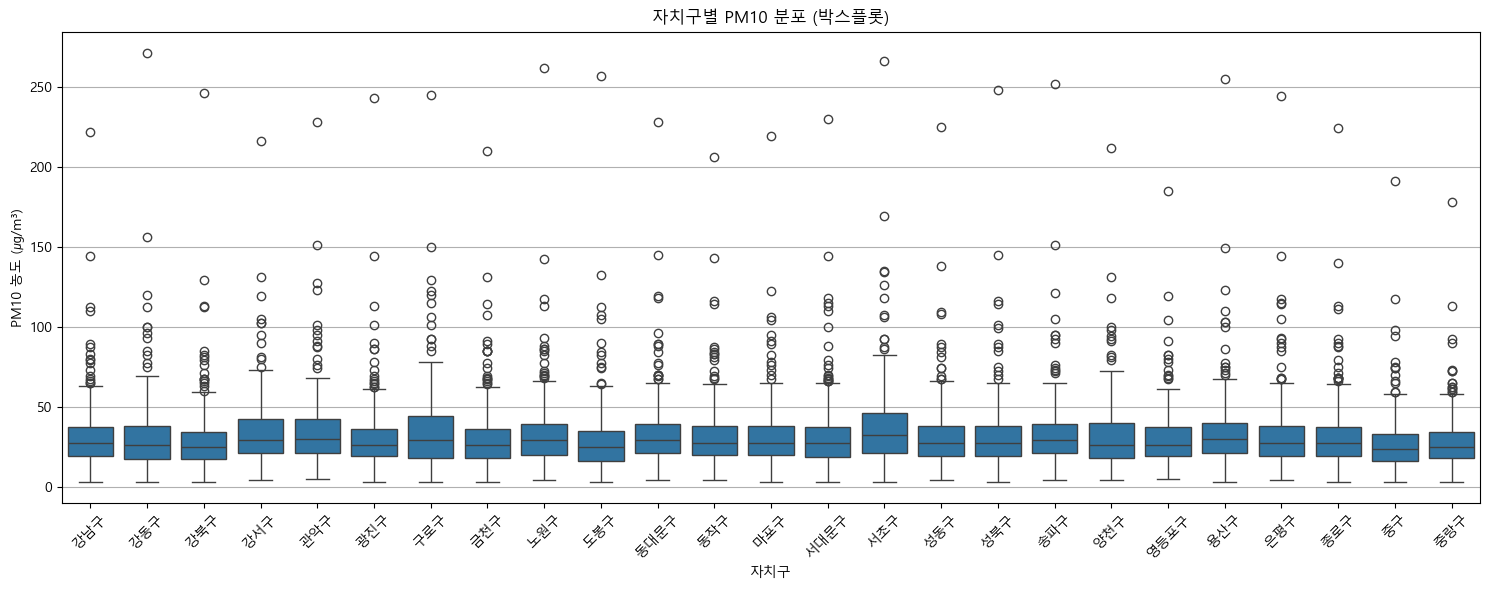

In [100]:
# 자치구별 이상치 확인하기
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize = (15, 6))

df_change = df_change[df_change["미세먼지"] < 500]

sns.boxplot(x = "구분", y = "미세먼지", data = df_change)
plt.title("자치구별 PM10 분포 (박스플롯)")
plt.xlabel("자치구")
plt.ylabel("PM10 농도 (㎍/m³)")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [101]:
# 이상치 개수 확인하기
outlier_records = []
outlier_counts = {}

for gu, group in df_change.groupby("구분"):
    Q1 = group["미세먼지"].quantile(0.25)
    Q3 = group["미세먼지"].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # 이상치 추출
    outliers = group[(group["미세먼지"] < lower) | (group["미세먼지"] > upper)].copy()
    outliers["자치구"] = gu
    outlier_counts[gu] = len(outliers)
    outlier_records.append(outliers[["자치구", "일자", "미세먼지"]])

outlier_dates_df = pd.concat(outlier_records, ignore_index=True)
outlier_series = pd.Series(outlier_counts).sort_values(ascending = False)

In [102]:
outlier_dates_df

,자치구,일자,미세먼지
0,강남구,1일,77.0
1,강남구,3일,112.0
2,강남구,4일,73.0
3,강남구,5일,80.0
4,강남구,10일,69.0
...,...,...,...
355,중랑구,18일,90.0
356,중랑구,19일,73.0
357,중랑구,26일,62.0
358,중랑구,29일,178.0


In [103]:
outlier_series

서대문구    19
금천구     19
동대문구    17
강북구     17
종로구     17
노원구     17
강남구     16
은평구     16
광진구     16
동작구     15
중랑구     15
용산구     14
도봉구     13
성동구     13
성북구     13
송파구     13
영등포구    13
관악구     13
중구      13
마포구     13
강동구     12
구로구     12
서초구     12
양천구     11
강서구     11
dtype: int64

# **자치구별 등급 분포 및 계절 변화량 확인하기**

### **등급 분포**

In [106]:
# 자치구별 등급 분포
def get_pm10_grade(value):
    if pd.isna(value):
        return "결측"
    elif value <= 30:
        return "좋음"
    elif value <= 80:
        return "보통"
    elif value <= 150:
        return "나쁨"
    else:
        return "매우나쁨"

In [159]:
# 각 등급 분포 표로 확인하기
gu_list = df_all["구분"].unique()

grade_summary_by_gu = {}

for gu in gu_list:
    gu_df = df_all[df_all["구분"] == gu].copy()
    
    # 날짜 컬럼만 추출
    day_columns = [col for col in gu_df.columns if "일" in col]
    
    # long-format으로 변환
    gu_long = gu_df.melt(id_vars=["월", "구분"],
                         value_vars=day_columns,
                         var_name="일",
                         value_name="PM10")
    
    # 등급 변환
    gu_long["등급"] = gu_long["PM10"].apply(get_pm10_grade)
    
    # 월별 등급 분포표
    grade_table = gu_long.groupby("월")["등급"].value_counts().unstack(fill_value=0)

    grade_table = grade_table.reindex(columns=["좋음", "보통", "나쁨", "매우나쁨", "결측"], fill_value=0)
    
    # 합계 행 추가
    grade_table.loc["합계"] = grade_table.sum()
    
    # 딕셔너리에 저장
    grade_summary_by_gu[gu] = grade_table

In [161]:
# 자치구별 히트맵
def draw_grade_heatmap(df, gu_name):
    # 해당 자치구만 추출
    gu_df = df[df["구분"] == gu_name].copy()

    # 일자 컬럼 추출 및 melt
    day_columns = [col for col in gu_df.columns if "일" in col]
    gu_long = gu_df.melt(id_vars=["월", "구분"], value_vars=day_columns,
                         var_name="일", value_name="PM10")

    # 등급화
    gu_long["등급"] = gu_long["PM10"].apply(get_pm10_grade)

    # 월-일 기준 등급 최빈값 테이블
    grade_table = gu_long.pivot_table(index="월", columns="일", values="등급",
                                      aggfunc=lambda x: x.mode()[0] if not x.mode().empty else "결측")

    # 등급 숫자 변환
    grade_map = {"좋음": 1, "보통": 2, "나쁨": 3, "매우나쁨": 4, "결측": 0}
    grade_numeric = grade_table.replace(grade_map)

    # 일자 정렬
    sorted_columns = sorted(grade_numeric.columns, key=lambda x: int(x.replace("일", "")))
    grade_numeric = grade_numeric[sorted_columns]

    # 히트맵 시각화
    plt.figure(figsize=(15, 6))
    sns.heatmap(grade_numeric, cmap="YlOrRd", linewidths=.5, annot=True, fmt="d",
                cbar_kws={'label': '등급 코드 (1=좋음 ~ 4=매우나쁨)'})
    plt.title(f"{gu_name} 미세먼지 등급 분포 (월-일 기준)")
    plt.xlabel("일")
    plt.ylabel("월")
    plt.show()


## **강남구**

C:\Users\lg\AppData\Local\Temp\ipykernel_15232\1776310093.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grade_numeric = grade_table.replace(grade_map)


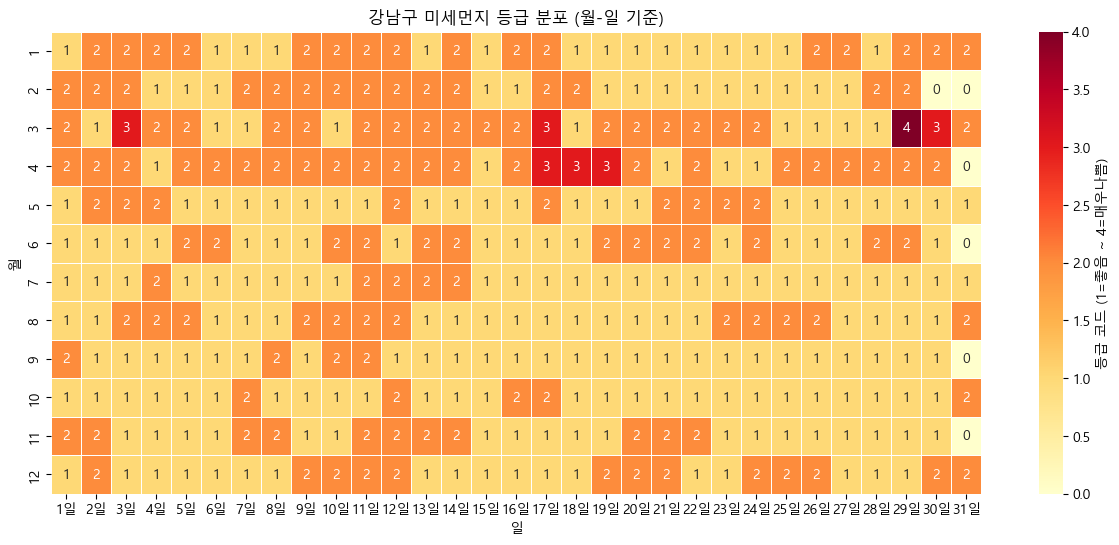

In [109]:
draw_grade_heatmap(df_all, "강남구")

In [163]:
grade_summary_by_gu["강남구"]

등급,좋음,보통,나쁨,매우나쁨,결측
월,,,,,
1,15,16,0,0,0
2,14,15,0,0,2
3,9,18,3,1,0
4,5,22,3,0,1
5,22,9,0,0,0
6,17,13,0,0,1
7,26,5,0,0,0
8,19,12,0,0,0
9,26,4,0,0,1


## **강동구**

C:\Users\lg\AppData\Local\Temp\ipykernel_15232\1776310093.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grade_numeric = grade_table.replace(grade_map)


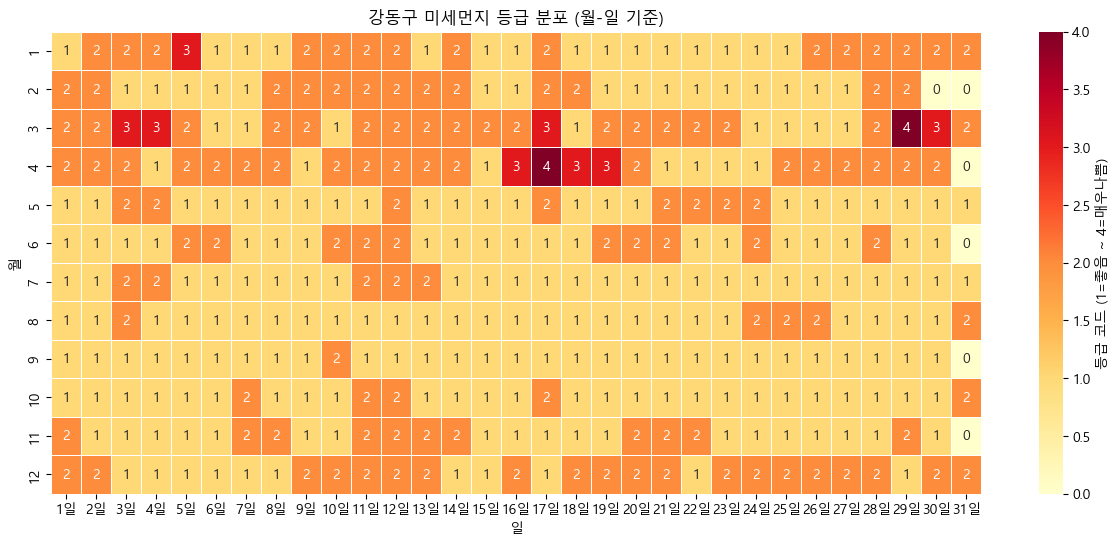

In [166]:
draw_grade_heatmap(df_all, "강동구")

In [167]:
grade_summary_by_gu["강동구"]

등급,좋음,보통,나쁨,매우나쁨,결측
월,,,,,
1,15,15,1,0,0
2,16,13,0,0,2
3,8,18,4,1,0
4,7,19,3,1,1
5,23,8,0,0,0
6,20,10,0,0,1
7,26,5,0,0,0
8,26,5,0,0,0
9,29,1,0,0,1


## **강북구**

C:\Users\lg\AppData\Local\Temp\ipykernel_15232\1776310093.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grade_numeric = grade_table.replace(grade_map)


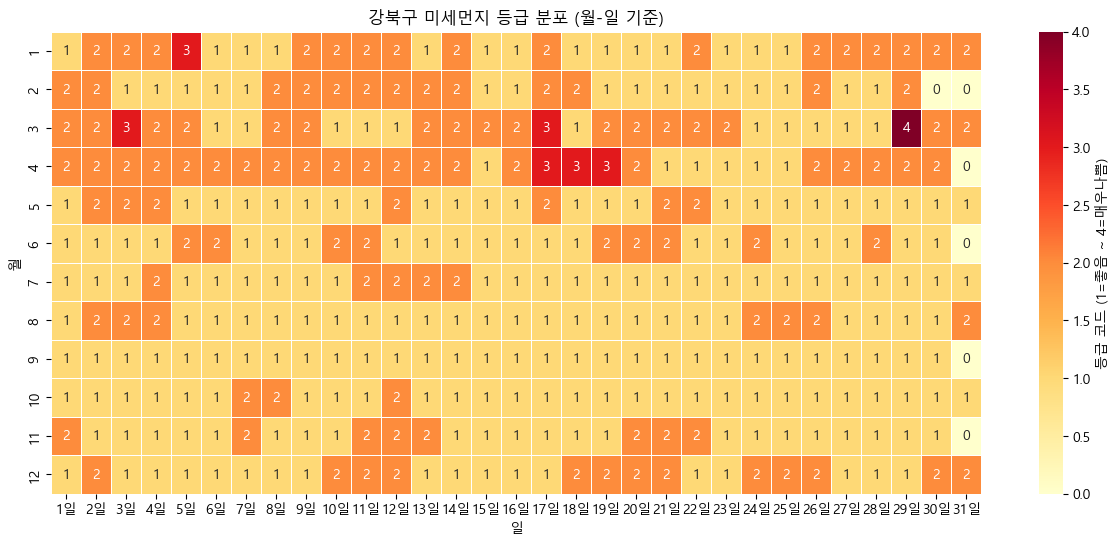

In [171]:
draw_grade_heatmap(df_all, "강북구")

In [172]:
grade_summary_by_gu["강북구"]

등급,좋음,보통,나쁨,매우나쁨,결측
월,,,,,
1,14,16,1,0,0
2,16,13,0,0,2
3,11,17,2,1,0
4,6,21,3,0,1
5,24,7,0,0,0
6,21,9,0,0,1
7,26,5,0,0,0
8,24,7,0,0,0
9,30,0,0,0,1


## **강서구**

C:\Users\lg\AppData\Local\Temp\ipykernel_15232\1776310093.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grade_numeric = grade_table.replace(grade_map)


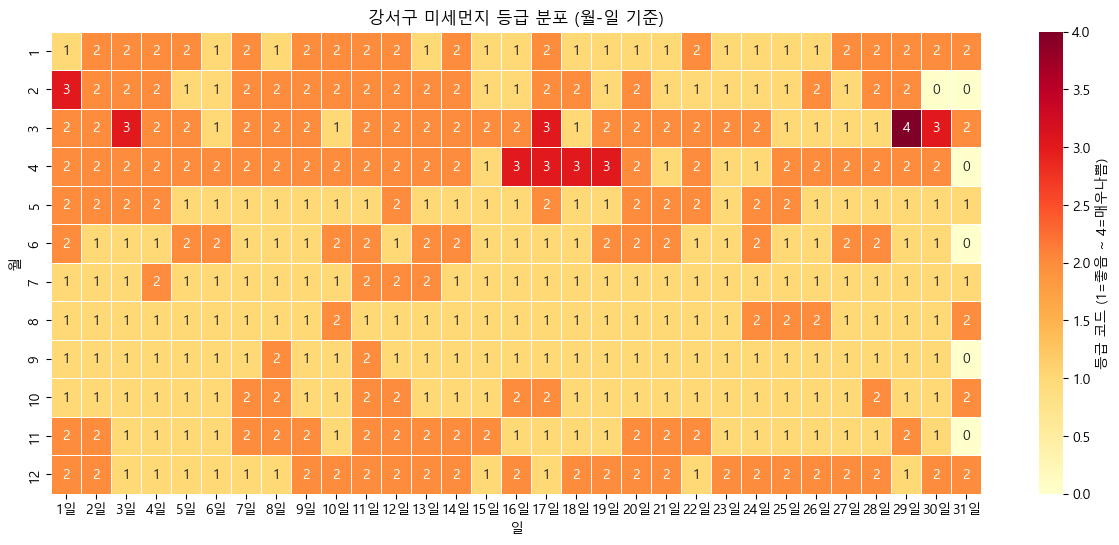

In [174]:
draw_grade_heatmap(df_all, "강서구")

In [175]:
grade_summary_by_gu["강서구"]

등급,좋음,보통,나쁨,매우나쁨,결측
월,,,,,
1,14,17,0,0,0
2,11,17,1,0,2
3,7,20,3,1,0
4,4,22,4,0,1
5,20,11,0,0,0
6,17,13,0,0,1
7,27,4,0,0,0
8,26,5,0,0,0
9,28,2,0,0,1


## **관악구**

C:\Users\lg\AppData\Local\Temp\ipykernel_15232\1776310093.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grade_numeric = grade_table.replace(grade_map)


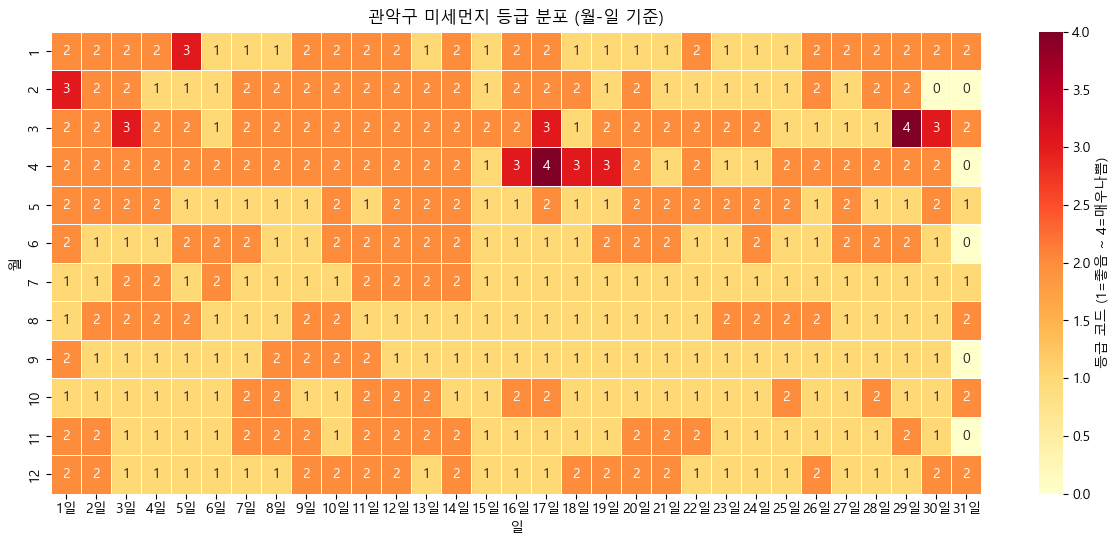

In [177]:
draw_grade_heatmap(df_all, "관악구")

In [178]:
grade_summary_by_gu["관악구"]

등급,좋음,보통,나쁨,매우나쁨,결측
월,,,,,
1,12,18,1,0,0
2,11,17,1,0,2
3,6,21,3,1,0
4,4,22,3,1,1
5,14,17,0,0,0
6,14,16,0,0,1
7,24,7,0,0,0
8,20,11,0,0,0
9,25,5,0,0,1


## **광진구**

C:\Users\lg\AppData\Local\Temp\ipykernel_15232\1776310093.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grade_numeric = grade_table.replace(grade_map)


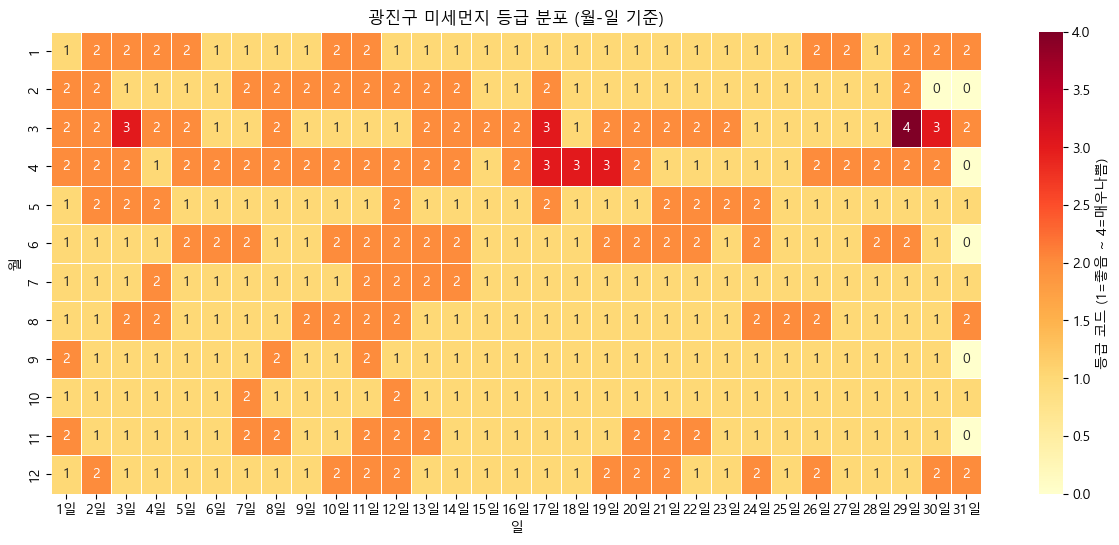

In [182]:
draw_grade_heatmap(df_all, "광진구")

In [183]:
grade_summary_by_gu["광진구"]

등급,좋음,보통,나쁨,매우나쁨,결측
월,,,,,
1,20,11,0,0,0
2,17,12,0,0,2
3,12,15,3,1,0
4,7,20,3,0,1
5,22,9,0,0,0
6,15,15,0,0,1
7,26,5,0,0,0
8,21,10,0,0,0
9,27,3,0,0,1


## **구로구**

C:\Users\lg\AppData\Local\Temp\ipykernel_15232\1776310093.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grade_numeric = grade_table.replace(grade_map)


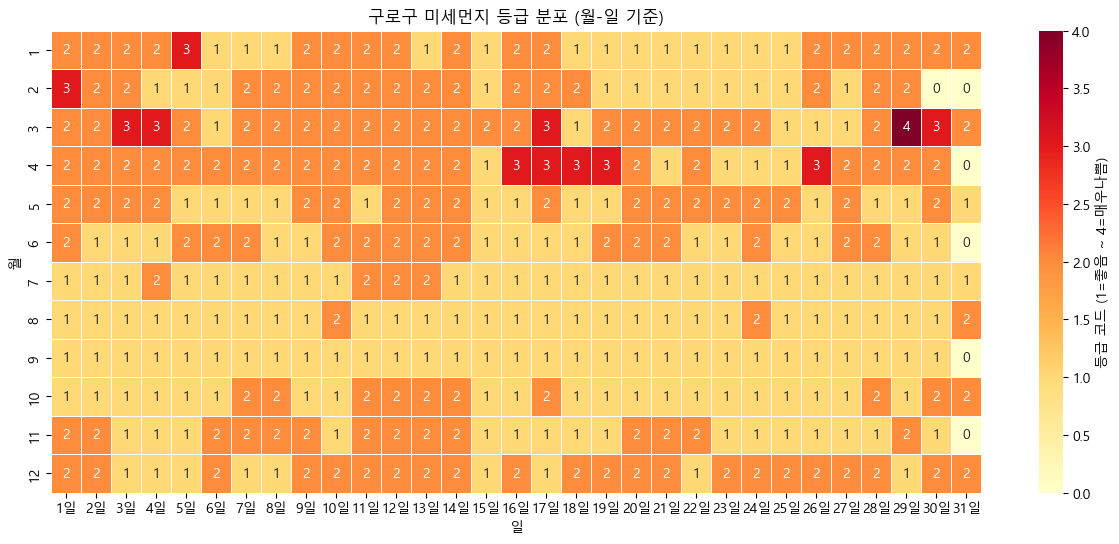

In [185]:
draw_grade_heatmap(df_all, "구로구")

In [186]:
grade_summary_by_gu["구로구"]

등급,좋음,보통,나쁨,매우나쁨,결측
월,,,,,
1,13,17,1,0,0
2,12,16,1,0,2
3,5,21,4,1,0
4,5,20,5,0,1
5,13,18,0,0,0
6,15,15,0,0,1
7,27,4,0,0,0
8,28,3,0,0,0
9,30,0,0,0,1


## **금천구**

C:\Users\lg\AppData\Local\Temp\ipykernel_15232\1776310093.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grade_numeric = grade_table.replace(grade_map)


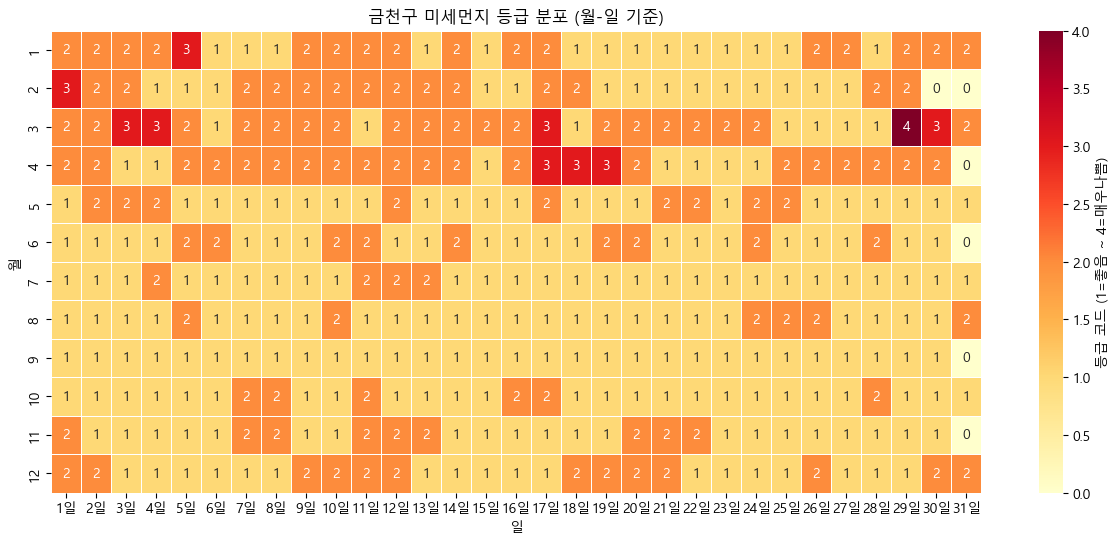

In [188]:
draw_grade_heatmap(df_all, "금천구")

In [191]:
grade_summary_by_gu["금천구"]

등급,좋음,보통,나쁨,매우나쁨,결측
월,,,,,
1,14,16,1,0,0
2,14,14,1,0,2
3,7,19,4,1,0
4,7,20,3,0,1
5,22,9,0,0,0
6,21,9,0,0,1
7,27,4,0,0,0
8,25,6,0,0,0
9,30,0,0,0,1


## **노원구**

C:\Users\lg\AppData\Local\Temp\ipykernel_15232\1776310093.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grade_numeric = grade_table.replace(grade_map)


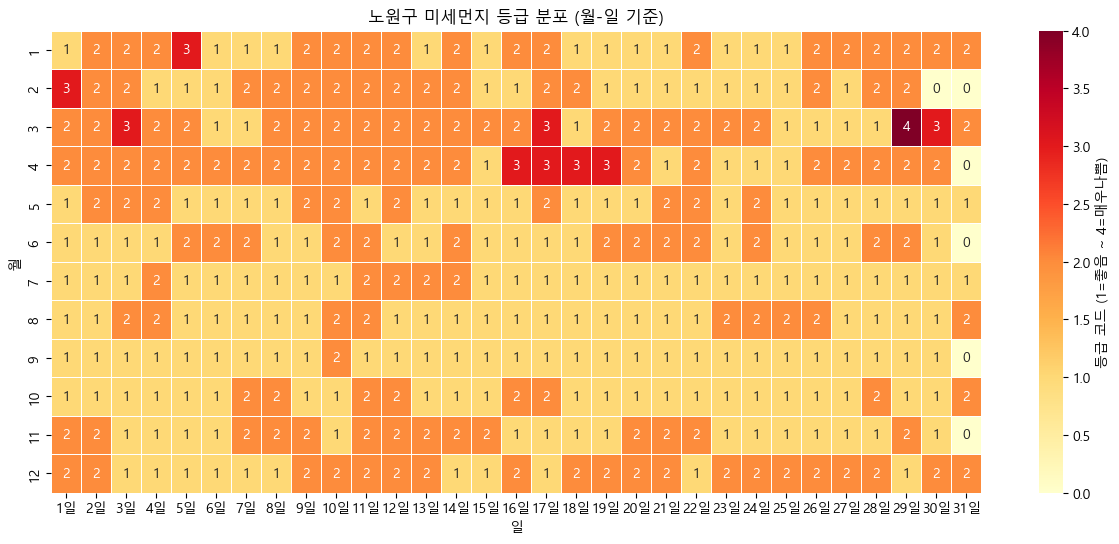

In [193]:
draw_grade_heatmap(df_all, "노원구")

In [194]:
grade_summary_by_gu["노원구"]

등급,좋음,보통,나쁨,매우나쁨,결측
월,,,,,
1,13,17,1,0,0
2,13,15,1,0,2
3,7,20,3,1,0
4,5,21,4,0,1
5,21,10,0,0,0
6,17,13,0,0,1
7,26,5,0,0,0
8,22,9,0,0,0
9,29,1,0,0,1


## **도봉구**

C:\Users\lg\AppData\Local\Temp\ipykernel_15232\1776310093.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grade_numeric = grade_table.replace(grade_map)


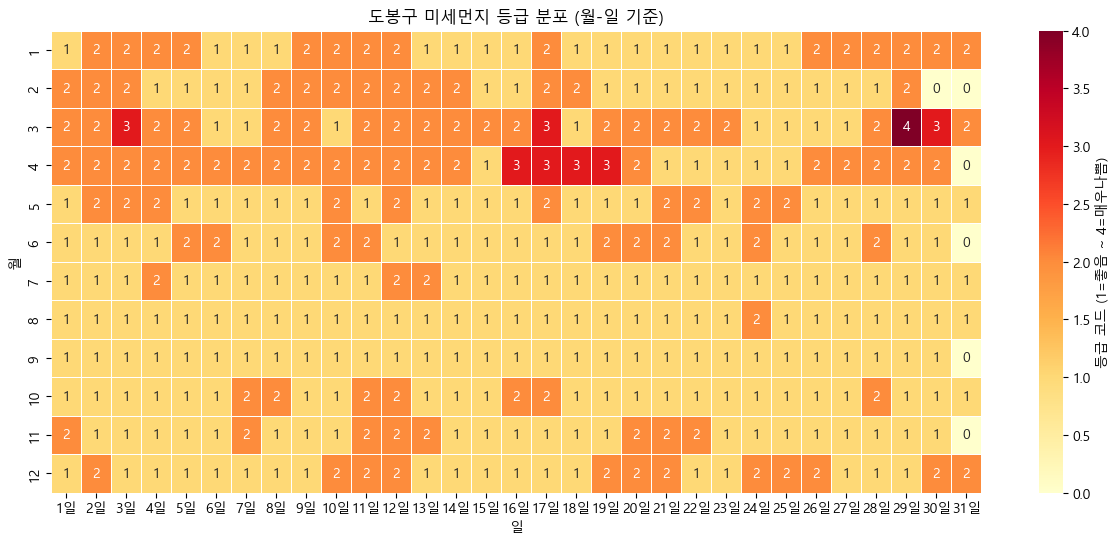

In [196]:
draw_grade_heatmap(df_all, "도봉구")

In [197]:
grade_summary_by_gu["도봉구"]

등급,좋음,보통,나쁨,매우나쁨,결측
월,,,,,
1,16,15,0,0,0
2,16,13,0,0,2
3,8,19,3,1,0
4,6,20,4,0,1
5,21,10,0,0,0
6,21,9,0,0,1
7,28,3,0,0,0
8,30,1,0,0,0
9,30,0,0,0,1


## **동대문구**

C:\Users\lg\AppData\Local\Temp\ipykernel_15232\1776310093.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grade_numeric = grade_table.replace(grade_map)


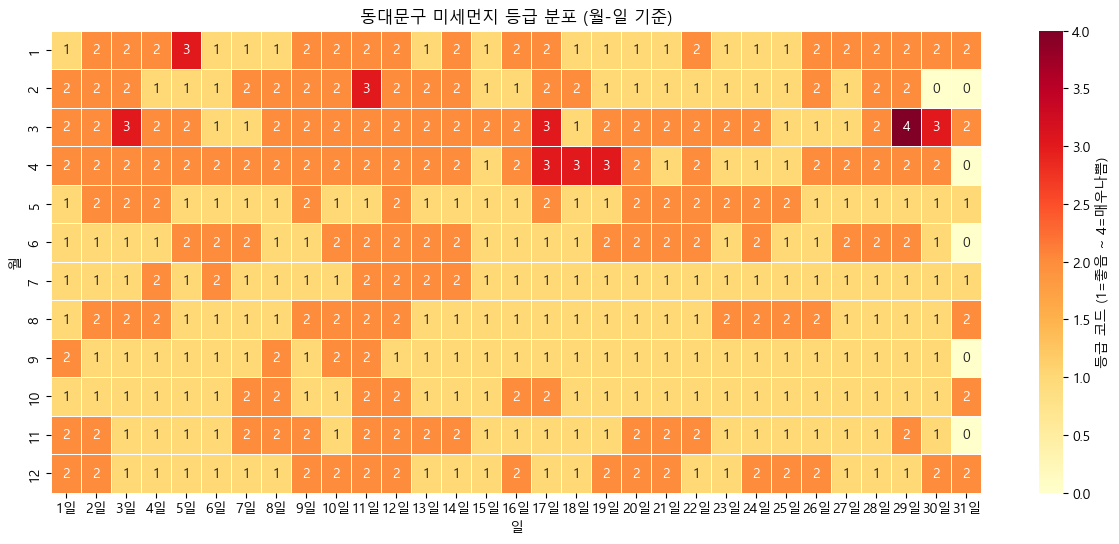

In [199]:
draw_grade_heatmap(df_all, "동대문구")

In [202]:
grade_summary_by_gu["동대문구"]

등급,좋음,보통,나쁨,매우나쁨,결측
월,,,,,
1,13,17,1,0,0
2,13,15,1,0,2
3,6,21,3,1,0
4,5,22,3,0,1
5,19,12,0,0,0
6,14,16,0,0,1
7,25,6,0,0,0
8,19,12,0,0,0
9,26,4,0,0,1


## **동작구**

C:\Users\lg\AppData\Local\Temp\ipykernel_15232\1776310093.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grade_numeric = grade_table.replace(grade_map)


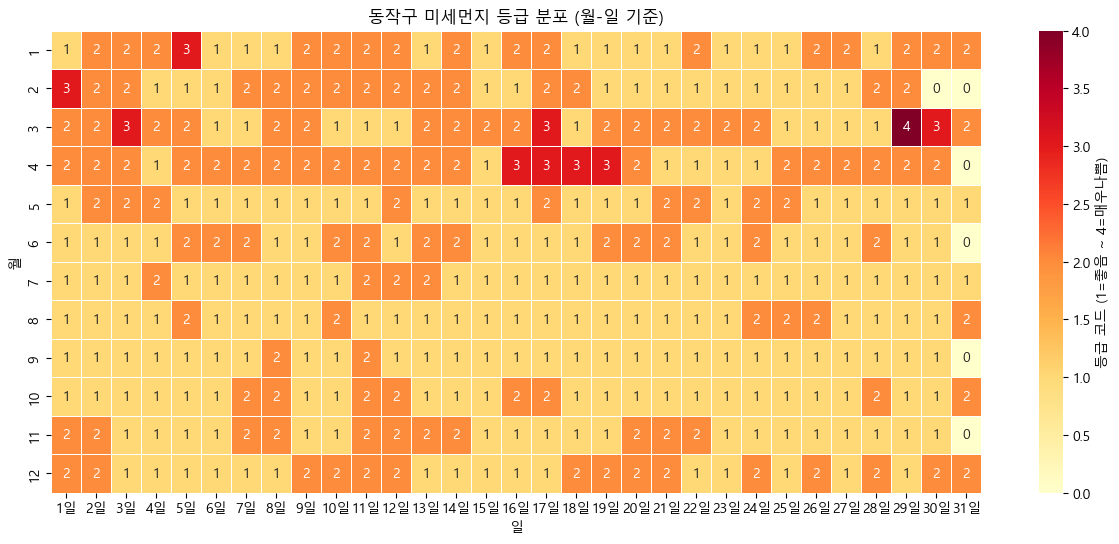

In [204]:
draw_grade_heatmap(df_all, "동작구")

In [205]:
grade_summary_by_gu["동작구"]

등급,좋음,보통,나쁨,매우나쁨,결측
월,,,,,
1,14,16,1,0,0
2,14,14,1,0,2
3,10,17,3,1,0
4,6,20,4,0,1
5,22,9,0,0,0
6,18,12,0,0,1
7,27,4,0,0,0
8,25,6,0,0,0
9,28,2,0,0,1


## **마포구**

C:\Users\lg\AppData\Local\Temp\ipykernel_15232\1776310093.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grade_numeric = grade_table.replace(grade_map)


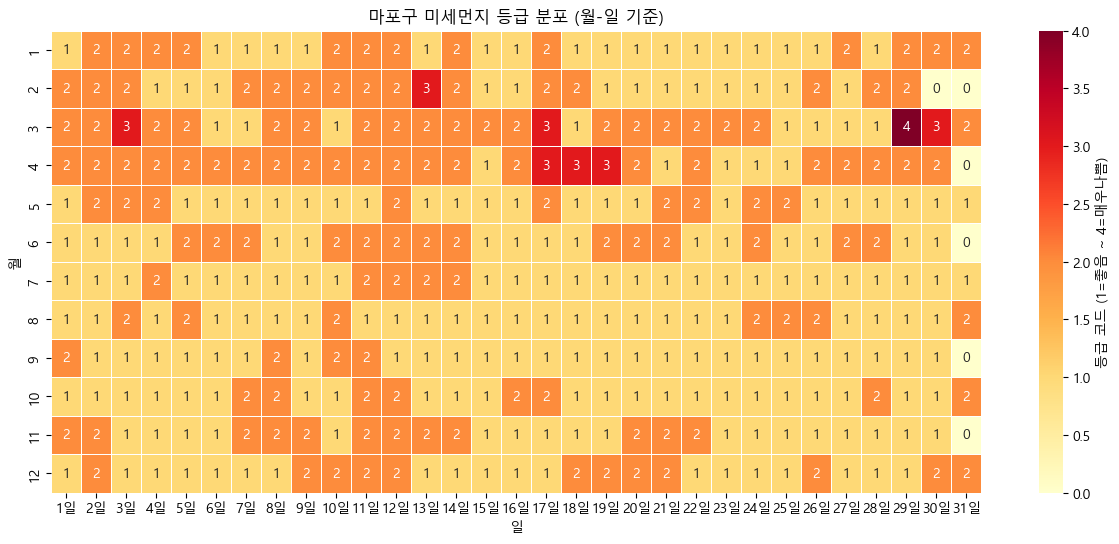

In [207]:
draw_grade_heatmap(df_all, "마포구")

In [208]:
grade_summary_by_gu["마포구"]

등급,좋음,보통,나쁨,매우나쁨,결측
월,,,,,
1,18,13,0,0,0
2,13,15,1,0,2
3,8,19,3,1,0
4,5,22,3,0,1
5,22,9,0,0,0
6,16,14,0,0,1
7,26,5,0,0,0
8,24,7,0,0,0
9,26,4,0,0,1


## **서대문구**

C:\Users\lg\AppData\Local\Temp\ipykernel_15232\1776310093.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grade_numeric = grade_table.replace(grade_map)


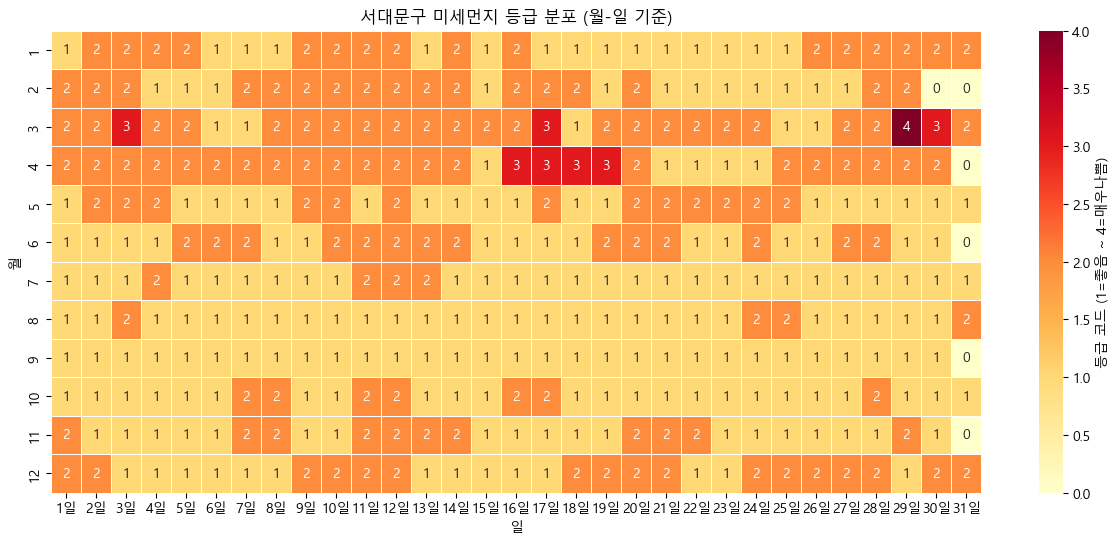

In [210]:
draw_grade_heatmap(df_all, "서대문구")

In [211]:
grade_summary_by_gu["서대문구"]

등급,좋음,보통,나쁨,매우나쁨,결측
월,,,,,
1,15,16,0,0,0
2,12,17,0,0,2
3,5,22,3,1,0
4,5,21,4,0,1
5,18,13,0,0,0
6,16,14,0,0,1
7,27,4,0,0,0
8,27,4,0,0,0
9,30,0,0,0,1


## **서초구**

C:\Users\lg\AppData\Local\Temp\ipykernel_15232\1776310093.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grade_numeric = grade_table.replace(grade_map)


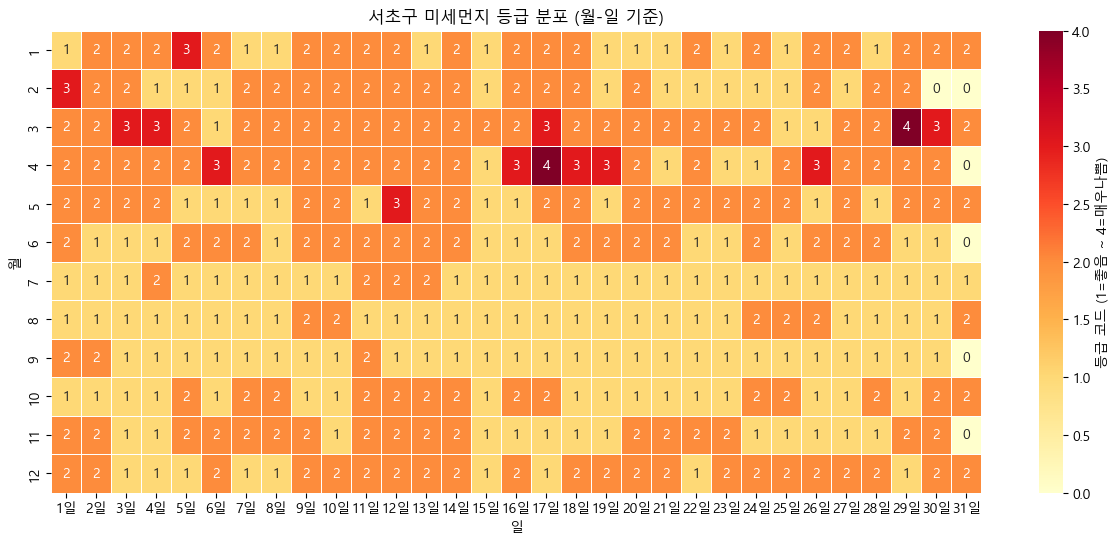

In [213]:
draw_grade_heatmap(df_all, "서초구")

In [214]:
grade_summary_by_gu["서초구"]

등급,좋음,보통,나쁨,매우나쁨,결측
월,,,,,
1,11,19,1,0,0
2,11,17,1,0,2
3,3,23,4,1,0
4,4,20,5,1,1
5,10,20,1,0,0
6,12,18,0,0,1
7,27,4,0,0,0
8,25,6,0,0,0
9,27,3,0,0,1


## **성동구**

C:\Users\lg\AppData\Local\Temp\ipykernel_15232\1776310093.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grade_numeric = grade_table.replace(grade_map)


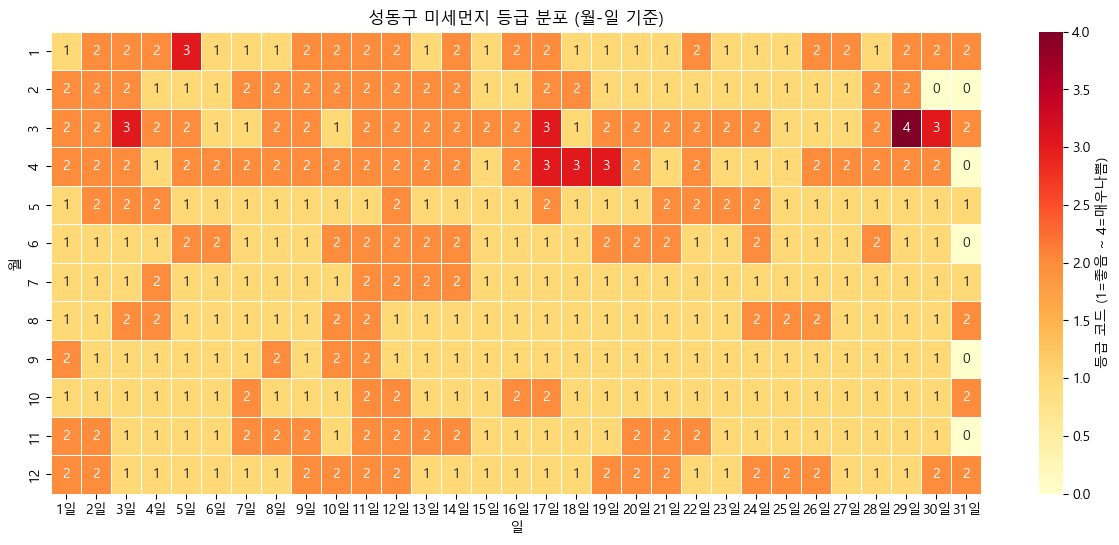

In [217]:
draw_grade_heatmap(df_all, "성동구")

In [219]:
grade_summary_by_gu["성동구"]

등급,좋음,보통,나쁨,매우나쁨,결측
월,,,,,
1,14,16,1,0,0
2,14,15,0,0,2
3,7,20,3,1,0
4,6,21,3,0,1
5,22,9,0,0,0
6,18,12,0,0,1
7,26,5,0,0,0
8,23,8,0,0,0
9,26,4,0,0,1


## **성북구**

C:\Users\lg\AppData\Local\Temp\ipykernel_15232\1776310093.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grade_numeric = grade_table.replace(grade_map)


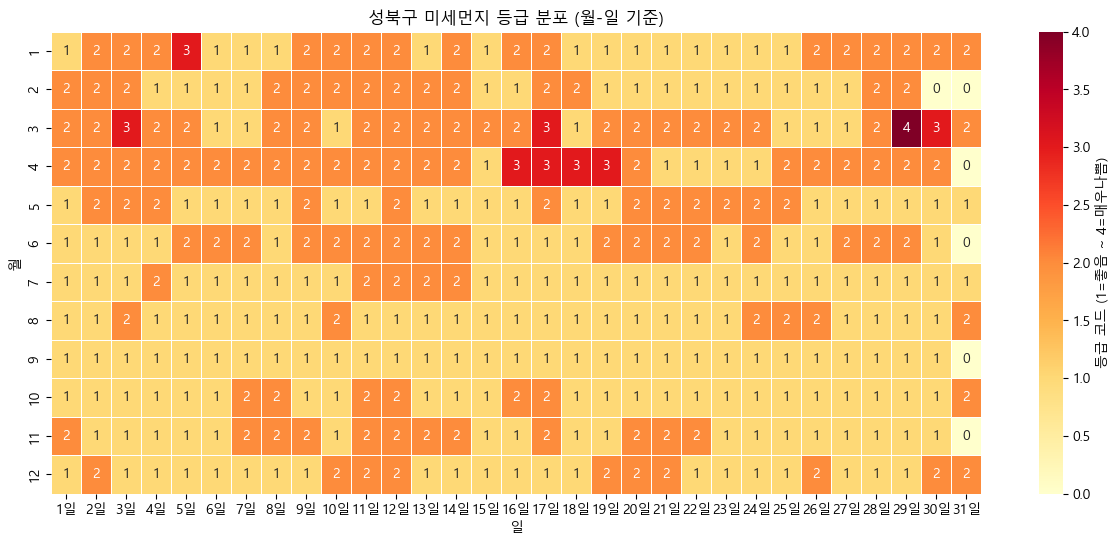

In [221]:
draw_grade_heatmap(df_all, "성북구")

In [222]:
grade_summary_by_gu["성북구"]

등급,좋음,보통,나쁨,매우나쁨,결측
월,,,,,
1,14,16,1,0,0
2,15,14,0,0,2
3,7,20,3,1,0
4,5,21,4,0,1
5,19,12,0,0,0
6,13,17,0,0,1
7,26,5,0,0,0
8,25,6,0,0,0
9,30,0,0,0,1


## **송파구**

C:\Users\lg\AppData\Local\Temp\ipykernel_15232\1776310093.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grade_numeric = grade_table.replace(grade_map)


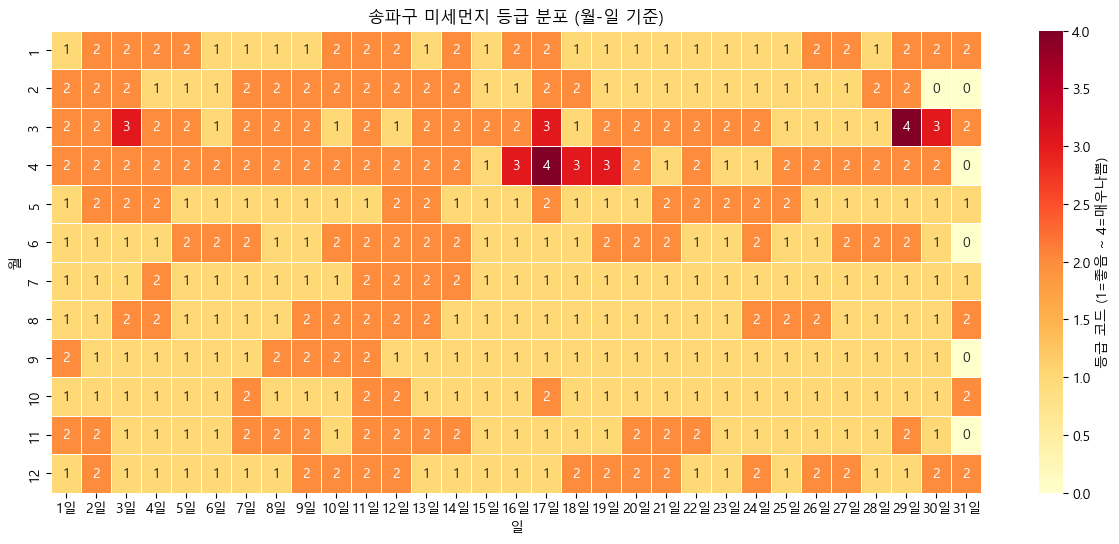

In [224]:
draw_grade_heatmap(df_all, "송파구")

In [225]:
grade_summary_by_gu["송파구"]

등급,좋음,보통,나쁨,매우나쁨,결측
월,,,,,
1,16,15,0,0,0
2,14,15,0,0,2
3,8,19,3,1,0
4,4,22,3,1,1
5,20,11,0,0,0
6,15,15,0,0,1
7,26,5,0,0,0
8,20,11,0,0,0
9,25,5,0,0,1


## **양천구**

C:\Users\lg\AppData\Local\Temp\ipykernel_15232\1776310093.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grade_numeric = grade_table.replace(grade_map)


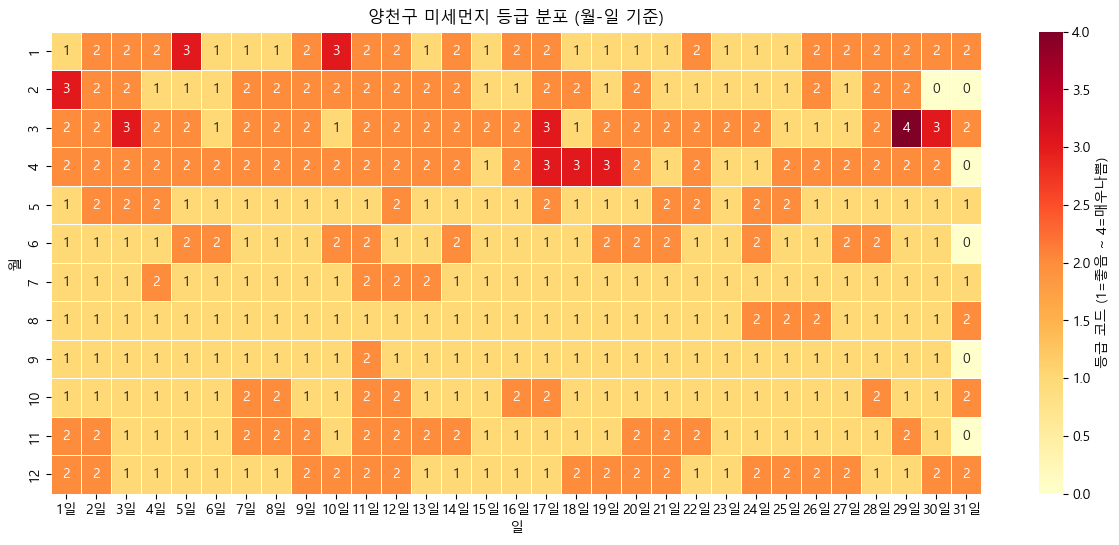

In [227]:
draw_grade_heatmap(df_all, "양천구")

In [228]:
grade_summary_by_gu["양천구"]

등급,좋음,보통,나쁨,매우나쁨,결측
월,,,,,
1,13,16,2,0,0
2,12,16,1,0,2
3,6,21,3,1,0
4,4,23,3,0,1
5,22,9,0,0,0
6,19,11,0,0,1
7,27,4,0,0,0
8,27,4,0,0,0
9,29,1,0,0,1


## **영등포구**

C:\Users\lg\AppData\Local\Temp\ipykernel_15232\1776310093.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grade_numeric = grade_table.replace(grade_map)


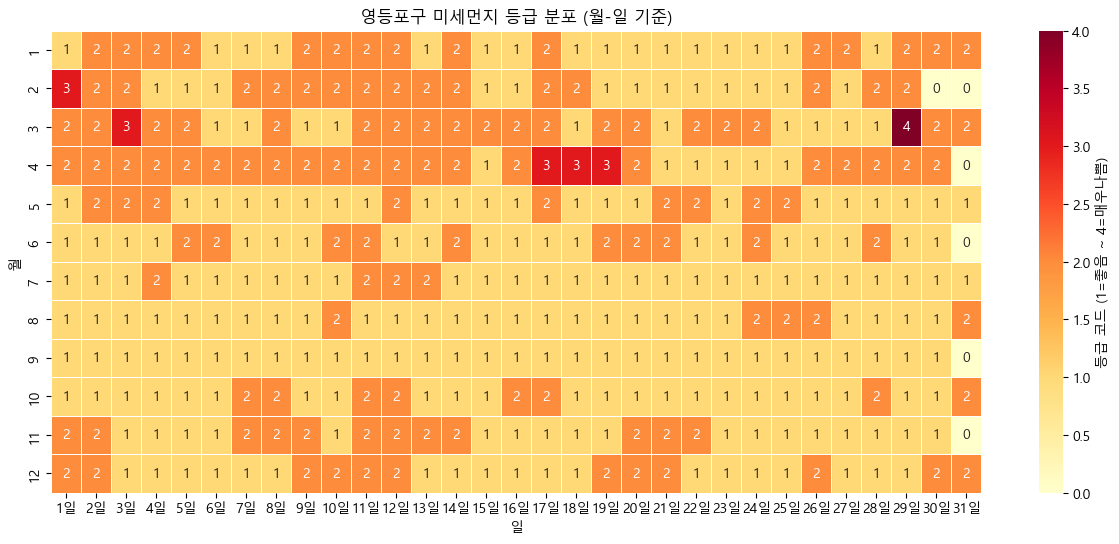

In [232]:
draw_grade_heatmap(df_all, "영등포구")

In [233]:
grade_summary_by_gu["영등포구"]

등급,좋음,보통,나쁨,매우나쁨,결측
월,,,,,
1,16,15,0,0,0
2,13,15,1,0,2
3,10,19,1,1,0
4,6,21,3,0,1
5,22,9,0,0,0
6,20,10,0,0,1
7,27,4,0,0,0
8,26,5,0,0,0
9,30,0,0,0,1


## **용산구**

C:\Users\lg\AppData\Local\Temp\ipykernel_15232\1776310093.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grade_numeric = grade_table.replace(grade_map)


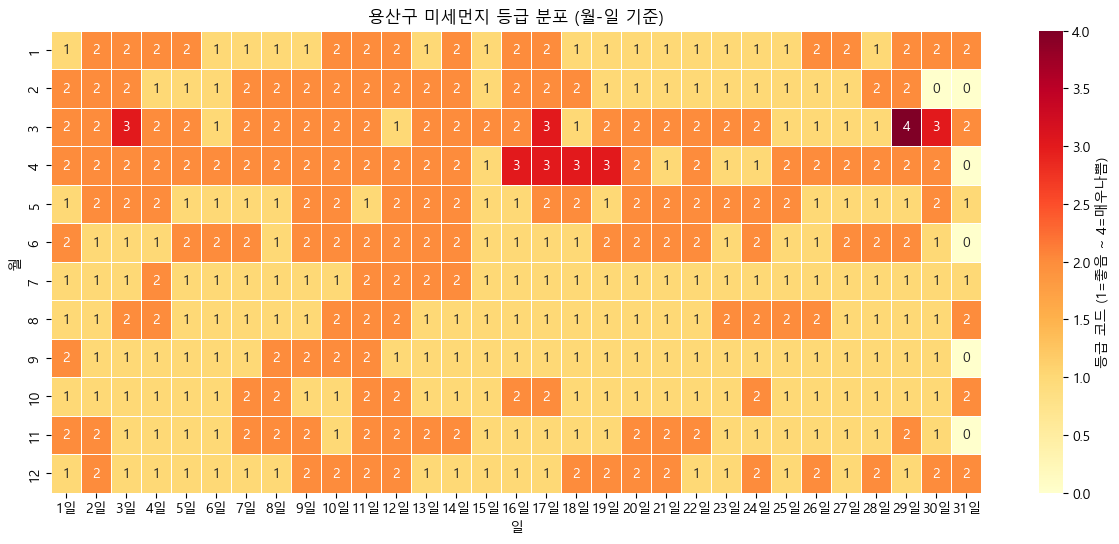

In [235]:
draw_grade_heatmap(df_all, "용산구")

In [236]:
grade_summary_by_gu["용산구"]

등급,좋음,보통,나쁨,매우나쁨,결측
월,,,,,
1,16,15,0,0,0
2,13,16,0,0,2
3,7,20,3,1,0
4,4,22,4,0,1
5,14,17,0,0,0
6,12,18,0,0,1
7,26,5,0,0,0
8,21,10,0,0,0
9,25,5,0,0,1


## **은평구**

C:\Users\lg\AppData\Local\Temp\ipykernel_15232\1776310093.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grade_numeric = grade_table.replace(grade_map)


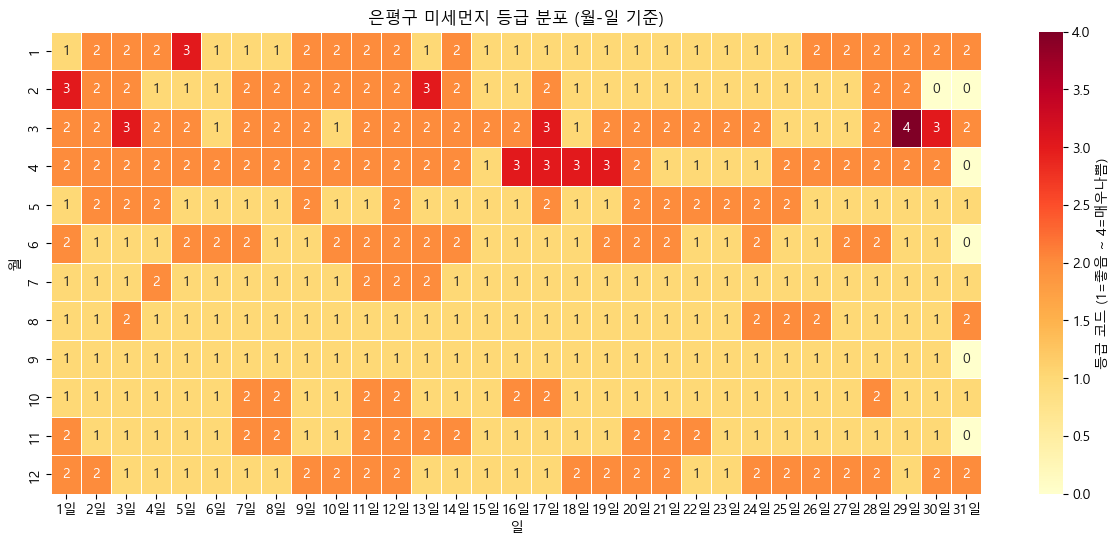

In [238]:
draw_grade_heatmap(df_all, "은평구")

In [239]:
grade_summary_by_gu["은평구"]

등급,좋음,보통,나쁨,매우나쁨,결측
월,,,,,
1,16,14,1,0,0
2,15,12,2,0,2
3,6,21,3,1,0
4,5,21,4,0,1
5,19,12,0,0,0
6,15,15,0,0,1
7,27,4,0,0,0
8,26,5,0,0,0
9,30,0,0,0,1


## **종로구**

C:\Users\lg\AppData\Local\Temp\ipykernel_15232\1776310093.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grade_numeric = grade_table.replace(grade_map)


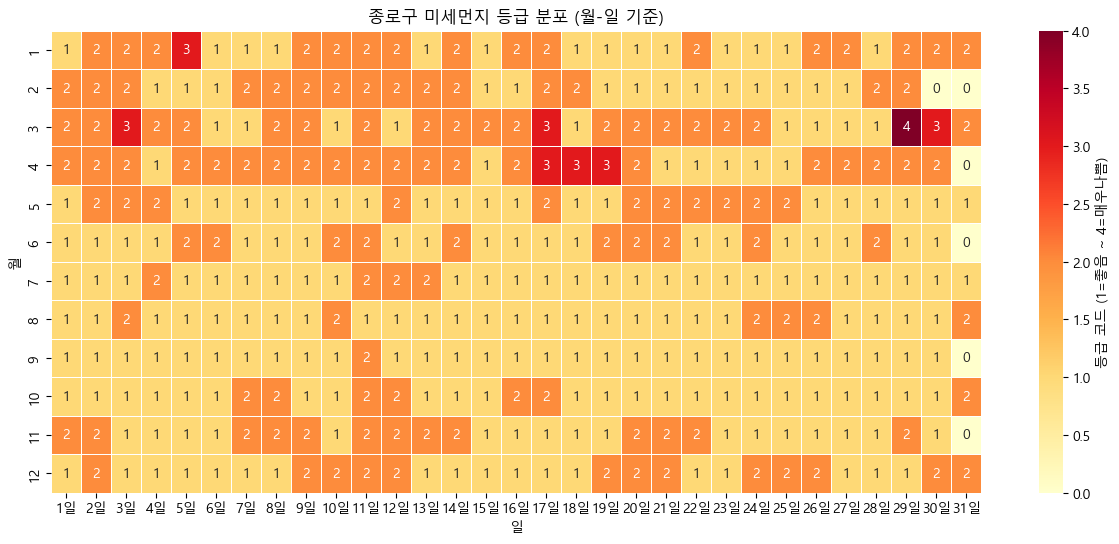

In [242]:
draw_grade_heatmap(df_all, "종로구")

In [243]:
grade_summary_by_gu["종로구"]

등급,좋음,보통,나쁨,매우나쁨,결측
월,,,,,
1,14,16,1,0,0
2,14,15,0,0,2
3,9,18,3,1,0
4,7,20,3,0,1
5,20,11,0,0,0
6,20,10,0,0,1
7,27,4,0,0,0
8,25,6,0,0,0
9,29,1,0,0,1


## **중구**

C:\Users\lg\AppData\Local\Temp\ipykernel_15232\1776310093.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grade_numeric = grade_table.replace(grade_map)


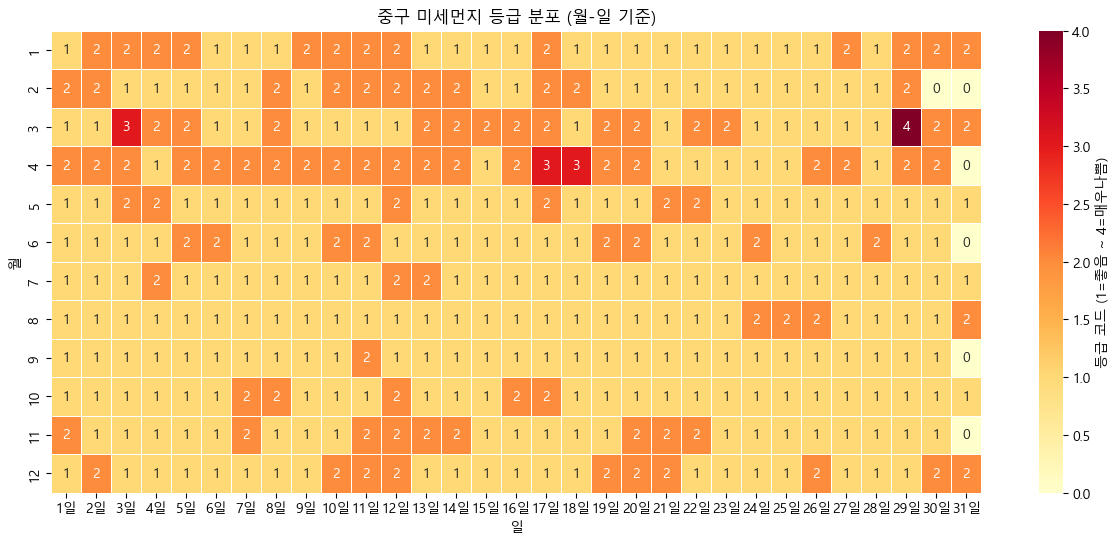

In [246]:
draw_grade_heatmap(df_all, "중구")

In [247]:
grade_summary_by_gu["중구"]

등급,좋음,보통,나쁨,매우나쁨,결측
월,,,,,
1,18,13,0,0,0
2,18,11,0,0,2
3,15,14,1,1,0
4,8,20,2,0,1
5,25,6,0,0,0
6,22,8,0,0,1
7,28,3,0,0,0
8,27,4,0,0,0
9,29,1,0,0,1


## **중랑구**

C:\Users\lg\AppData\Local\Temp\ipykernel_15232\1776310093.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grade_numeric = grade_table.replace(grade_map)


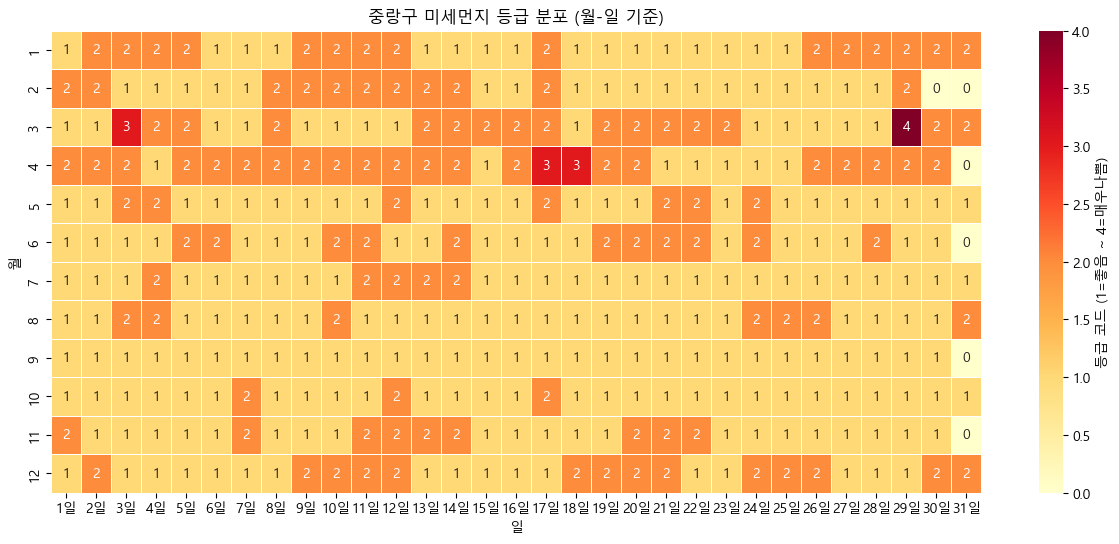

In [249]:
draw_grade_heatmap(df_all, "중랑구")

In [250]:
grade_summary_by_gu["중랑구"]

등급,좋음,보통,나쁨,매우나쁨,결측
월,,,,,
1,16,15,0,0,0
2,18,11,0,0,2
3,14,15,1,1,0
4,7,21,2,0,1
5,24,7,0,0,0
6,19,11,0,0,1
7,26,5,0,0,0
8,24,7,0,0,0
9,30,0,0,0,1


- 각 미세먼지를 살펴본 결과,
    - 3월 29일은 전부 등급 분포 4가 나옴. 이날 무슨 일이 있었는가..
    - 중구와 종로구는 '나쁨' 등급이 상대적으로 적은 것으로 나타남
    - 반면, 구로구, 서초구, 은평구는 '나쁨' 등급이 10번 이상 나타나는 것을 확인할 수 있음

# **계절 변화량 살펴보기**

In [255]:
def get_season(month):
    if month in [3, 4, 5]:
        return "봄"
    elif month in [6, 7, 8]:
        return "여름"
    elif month in [9, 10, 11]:
        return "가을"
    else:
        return "겨울"

# 계절 컬럼 추가
df_all["계절"] = df_all["월"].apply(get_season)

In [256]:
df_all

3,구분,1일,2일,3일,4일,5일,6일,7일,8일,9일,...,24일,25일,26일,27일,28일,29일,30일,31일,월,계절
0,강남구,24,41.0,44,53,80,23,23.0,23,33,...,22.0,21,34,53,29,44,58.0,55.0,1,겨울
1,강동구,21,38.0,41,56,85,26,21.0,22,31,...,19.0,23,38,59,35,46,57.0,53.0,1,겨울
2,강북구,20,34.0,36,54,82,22,23.0,23,34,...,22.0,21,33,49,33,41,52.0,56.0,1,겨울
3,강서구,29,43.0,46,53,60,30,33.0,24,34,...,24.0,21,26,53,31,49,64.0,69.0,1,겨울
4,관악구,34,44.0,49,52,91,25,25.0,24,36,...,23.0,22,38,54,33,46,65.0,62.0,1,겨울
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,용산구,29,40.0,17,22,22,25,23.0,23,33,...,31.0,30,61,30,31,24,52.0,52.0,12,겨울
296,은평구,32,48.0,18,25,23,27,24.0,24,32,...,32.0,32,68,32,32,24,61.0,55.0,12,겨울
297,종로구,30,45.0,16,21,21,24,22.0,21,32,...,33.0,34,63,29,29,24,55.0,51.0,12,겨울
298,중구,30,40.0,12,17,16,19,18.0,18,28,...,29.0,30,56,24,24,22,48.0,42.0,12,겨울


In [257]:
# 자치구를 기준으로 데이터 변경하기
day_columns = [f'{i}일' for i in range(1, 32)]

df_change = df_all.melt(id_vars = ["구분", "계절"],
                     value_vars = day_columns,
                     var_name = "일자",
                     value_name = "미세먼지")

df_change

,구분,계절,일자,미세먼지
0,강남구,겨울,1일,24.0
1,강동구,겨울,1일,21.0
2,강북구,겨울,1일,20.0
3,강서구,겨울,1일,29.0
4,관악구,겨울,1일,34.0
...,...,...,...,...
9295,용산구,겨울,31일,52.0
9296,은평구,겨울,31일,55.0
9297,종로구,겨울,31일,51.0
9298,중구,겨울,31일,42.0


In [260]:
# 평균 대비 게절별 변화량 확인하기
season_mean = df_change.groupby(["구분", "계절"])["미세먼지"].mean().unstack()
season_mean["계절변화폭"] = season_mean.max(axis = 1) - season_mean.min(axis = 1)
season_mean_sorted = season_mean.sort_values(by = "계절변화폭", ascending = False)
season_mean_sorted = season_mean_sorted.reindex(columns=["봄", "여름", "가을", "겨울", "계절변화폭"], fill_value=0)

In [261]:
season_mean_sorted.head()

계절,봄,여름,가을,겨울,계절변화폭
구분,,,,,
서초구,54.434783,25.967391,25.082656,39.235804,29.352126
구로구,49.804348,23.619565,23.650823,38.934066,26.184783
서대문구,45.326087,24.086957,20.296703,34.186813,25.029384
은평구,45.054348,24.771739,21.736264,34.615385,23.318084
도봉구,42.576087,20.250000,21.241758,31.989011,22.326087


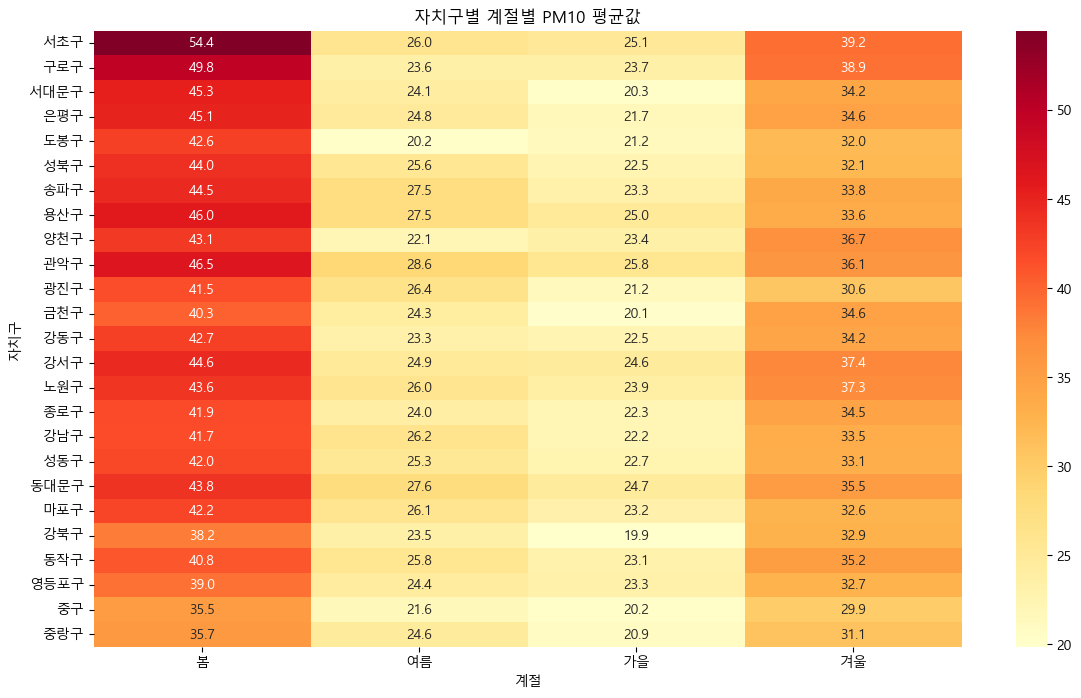

In [263]:
plt.figure(figsize=(14, 8))

season_mean_sorted = season_mean_sorted.reindex(columns=["봄", "여름", "가을", "겨울", "계절변화폭"], fill_value=0)

sns.heatmap(season_mean_sorted.drop(columns="계절변화폭"), annot=True, cmap="YlOrRd", fmt=".1f")
plt.title("자치구별 계절별 PM10 평균값")
plt.xlabel("계절")
plt.ylabel("자치구")
plt.show()

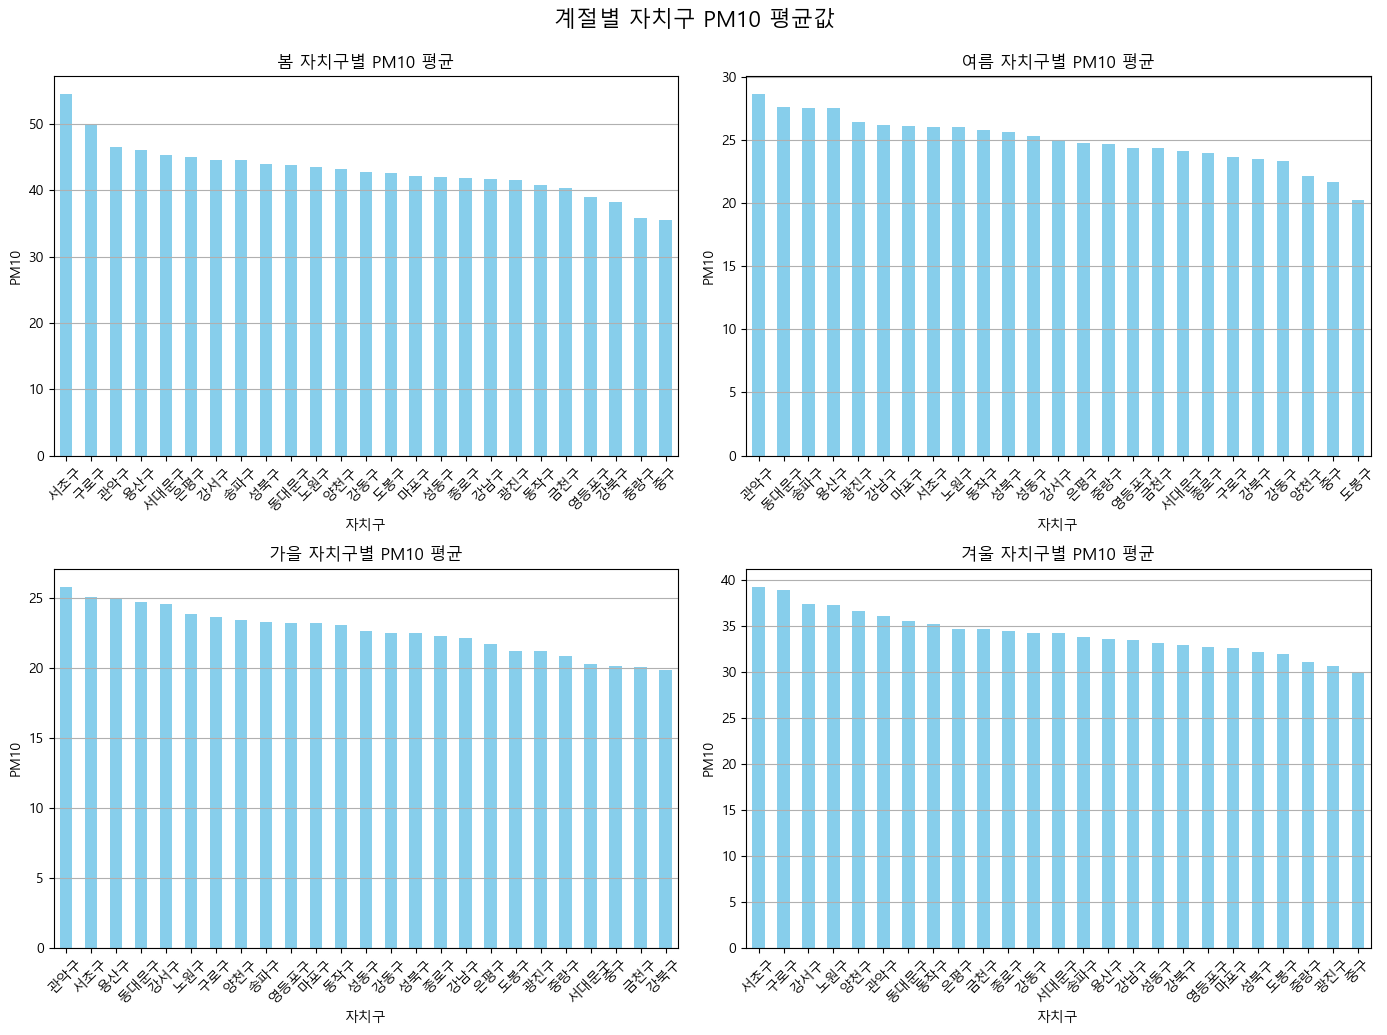

In [265]:
fig, axes = plt.subplots(2, 2, figsize = (14, 10))
axes = axes.flatten()

seasons = ["봄", "여름", "가을", "겨울"]

for i, season in enumerate(seasons):
    ax = axes[i]
    season_mean[season].sort_values(ascending = False).plot(kind = "bar", ax = ax, color = "skyblue")
    ax.set_title(f'{season} 자치구별 PM10 평균')
    ax.set_xlabel("자치구")
    ax.set_ylabel("PM10")
    ax.tick_params(axis = "x", rotation = 45)
    ax.grid(axis = "y")

plt.tight_layout()
plt.suptitle("계절별 자치구 PM10 평균값", fontsize = 16, y = 1.03)
plt.show()

# **지도로 표현하기**

In [305]:
geo_path = "./data/seoul_municipalities_geo_simple.json"
geo_path_str = json.load(open(geo_path, encoding = "utf-8"))

In [333]:
geo_path_str

{'type': 'FeatureCollection',
 'features': [{'type': 'Feature',
   'geometry': {'type': 'Polygon',
    'coordinates': [[[127.05181987399999, 37.685815952999974],
      [127.05195432999994, 37.68295554600002],
      [127.05124372099999, 37.68200315500002],
      [127.050936224, 37.68010014399999],
      [127.04973706099997, 37.676724165999985],
      [127.04887969799995, 37.67518859900002],
      [127.04820611399998, 37.67048413200001],
      [127.04893704599999, 37.667590002],
      [127.05142672199997, 37.663973570999985],
      [127.051469816, 37.66042898699999],
      [127.05343323299996, 37.65751023399997],
      [127.054073077, 37.654496732999974],
      [127.05376492699997, 37.652060053000014],
      [127.05396756200003, 37.650582568],
      [127.05545541100003, 37.64824690299997],
      [127.05584227600002, 37.64705617300001],
      [127.05566746900001, 37.64460474399999],
      [127.05516606799995, 37.643454948],
      [127.05513914699998, 37.64133787499998],
      [127.0547437

In [310]:
m = folium.Map(location=[37.5665, 126.9780], zoom_start=11)

In [414]:
# 계절변화폭을 따로 빼두기
variation = season_mean_by_gu_sorted["계절변화폭"]

# 계절별 평균만 long-format으로 변환
season_long = season_mean_by_gu_sorted.drop(columns="계절변화폭").reset_index().melt(id_vars="구분", var_name="계절", value_name="PM10")

# 계절변화폭 다시 merge
season_long = season_long.merge(variation.reset_index(), on="구분")

season_long.head()

,구분,계절,PM10,계절변화폭
0,서초구,봄,54.434783,29.352126
1,구로구,봄,49.804348,26.184783
2,서대문구,봄,45.326087,25.029384
3,은평구,봄,45.054348,23.318084
4,도봉구,봄,42.576087,22.326087


In [404]:
my_map = folium.Map(
    location = [37.5502, 126.982],
    zoom_start = 11,
)

season_long = season_long[season_long["계절"] == "봄"]

folium.Choropleth(
    geo_data = geo_path_str,
    data = season_long,
    columns = ["구분", "PM10"],
    key_on = "feature.properties.SIG_KOR_NM",
    fill_color = "YlOrRd",
    fill_opacity = 0.7,
    line_opacity = 0.2,
    legend_name = "지역별 PM10"
).add_to(my_map)

my_map

In [408]:
my_map = folium.Map(
    location = [37.5502, 126.982],
    zoom_start = 11,
)

season_long = season_long[season_long["계절"] == "여름"]

folium.Choropleth(
    geo_data = geo_path_str,
    data = season_long,
    columns = ["구분", "PM10"],
    key_on = "feature.properties.SIG_KOR_NM",
    fill_color = "YlOrRd",
    fill_opacity = 0.7,
    line_opacity = 0.2,
    legend_name = "지역별 PM10"
).add_to(my_map)

my_map

In [412]:
my_map = folium.Map(
    location = [37.5502, 126.982],
    zoom_start = 11,
)

season_long = season_long[season_long["계절"] == "가을"]

folium.Choropleth(
    geo_data = geo_path_str,
    data = season_long,
    columns = ["구분", "PM10"],
    key_on = "feature.properties.SIG_KOR_NM",
    fill_color = "YlOrRd",
    fill_opacity = 0.7,
    line_opacity = 0.2,
    legend_name = "지역별 PM10"
).add_to(my_map)

my_map

In [416]:
my_map = folium.Map(
    location = [37.5502, 126.982],
    zoom_start = 11,
)

season_long = season_long[season_long["계절"] == "겨울"]

folium.Choropleth(
    geo_data = geo_path_str,
    data = season_long,
    columns = ["구분", "PM10"],
    key_on = "feature.properties.SIG_KOR_NM",
    fill_color = "YlOrRd",
    fill_opacity = 0.7,
    line_opacity = 0.2,
    legend_name = "지역별 PM10"
).add_to(my_map)

my_map